# 1. Importación de librerías

In [2]:
# Librerías de análisis
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# 2. Carga del dataset

In [3]:
df = pd.read_csv("../data/processed/coffee_data_cleaned_final.csv")

# 3. Vista inicial del DataFrame

In [4]:
df.head()

,Species,Owner,Country.of.Origin,Region,Number.of.Bags,Bag.Weight,In.Country.Partner,Grading.Date,Variety,Processing.Method,...,Balance,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Color,Category.Two.Defects,altitude_mean_meters,categoria_altitud,Nombre_Comercial
0,Arabica,metad plc,Ethiopia,guji-hambela,300,60 kg,METAD Agricultural Development plc,"April 4th, 2015",Other,Washed / Wet,...,8.42,8.75,90.58,0.12,0,Green,0,2075.0,Premium (Arabica),Private Reserve MET
1,Arabica,metad plc,Ethiopia,guji-hambela,300,60 kg,METAD Agricultural Development plc,"April 4th, 2015",Other,Washed / Wet,...,8.42,8.58,89.92,0.12,0,Green,1,2075.0,Premium (Arabica),Private Reserve MET
2,Arabica,grounds for health admin,Guatemala,Other,5,1,Specialty Coffee Association,"May 31st, 2010",Bourbon,Washed / Wet,...,8.42,9.25,89.75,0.00,0,Green,0,1700.0,Alta (Arabica),Mill GRO
3,Arabica,yidnekachew dabessa,Ethiopia,oromia,320,60 kg,METAD Agricultural Development plc,"March 26th, 2015",Other,Natural / Dry,...,8.25,8.67,89.00,0.11,0,Green,2,2000.0,Premium (Arabica),Heritage YID
4,Arabica,metad plc,Ethiopia,guji-hambela,300,60 kg,METAD Agricultural Development plc,"April 4th, 2015",Other,Washed / Wet,...,8.33,8.58,88.83,0.12,0,Green,2,2075.0,Premium (Arabica),Private Reserve MET


# 4. Dimensión del DataFrame

In [5]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 1332
Columnas: 25


# 5. Nombres de las columnas

In [6]:
df.columns.tolist()

['Species',
 'Owner',
 'Country.of.Origin',
 'Region',
 'Number.of.Bags',
 'Bag.Weight',
 'In.Country.Partner',
 'Grading.Date',
 'Variety',
 'Processing.Method',
 'Aroma',
 'Flavor',
 'Aftertaste',
 'Acidity',
 'Body',
 'Balance',
 'Cupper.Points',
 'Total.Cup.Points',
 'Moisture',
 'Category.One.Defects',
 'Color',
 'Category.Two.Defects',
 'altitude_mean_meters',
 'categoria_altitud',
 'Nombre_Comercial']

# 6. Tipos de variables

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1332 entries, 0 to 1331
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Species               1332 non-null   str    
 1   Owner                 1332 non-null   str    
 2   Country.of.Origin     1332 non-null   str    
 3   Region                1332 non-null   str    
 4   Number.of.Bags        1332 non-null   int64  
 5   Bag.Weight            1332 non-null   str    
 6   In.Country.Partner    1332 non-null   str    
 7   Grading.Date          1332 non-null   str    
 8   Variety               1332 non-null   str    
 9   Processing.Method     1332 non-null   str    
 10  Aroma                 1332 non-null   float64
 11  Flavor                1332 non-null   float64
 12  Aftertaste            1332 non-null   float64
 13  Acidity               1332 non-null   float64
 14  Body                  1332 non-null   float64
 15  Balance               1332 non-n

# 7. Estadísticas descriptivas

In [8]:
df.describe()

,Number.of.Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Category.Two.Defects,altitude_mean_meters
count,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000,1332.000000
mean,154.316066,7.573438,7.526787,7.407260,7.541839,7.523724,7.524242,7.509715,82.155578,0.088416,0.481982,3.554805,1170.860665
std,129.951005,0.316083,0.341734,0.350759,0.319328,0.308143,0.354193,0.427587,2.691183,0.048265,2.556142,5.313253,574.351276
min,0.000000,5.080000,6.080000,6.170000,5.250000,5.080000,5.250000,5.170000,59.830000,0.000000,0.000000,0.000000,1.000000
25%,14.000000,7.420000,7.330000,7.250000,7.330000,7.330000,7.330000,7.250000,81.170000,0.090000,0.000000,0.000000,800.000000
50%,175.000000,7.580000,7.580000,7.420000,7.580000,7.500000,7.500000,7.500000,82.500000,0.110000,0.000000,2.000000,1250.000000
75%,275.000000,7.750000,7.750000,7.670000,7.750000,7.670000,7.750000,7.750000,83.670000,0.120000,0.000000,4.000000,1600.000000
max,1062.000000,8.750000,8.830000,8.670000,8.750000,8.580000,8.750000,10.000000,90.580000,0.280000,63.000000,55.000000,3850.000000


# 8. Análisis de valores faltantes

In [9]:
nulos = df.isnull().sum()
porcentaje = (nulos / len(df)) * 100

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': porcentaje.round(2)
}).sort_values('Nulos', ascending=False)

resultado = resumen_nulos[resumen_nulos['Nulos'] > 0]

if resultado.empty:
    print("No hay valores nulos en el DataFrame.")
else:
    display(resultado)

No hay valores nulos en el DataFrame.


# 9. Distribución de variables numéricas

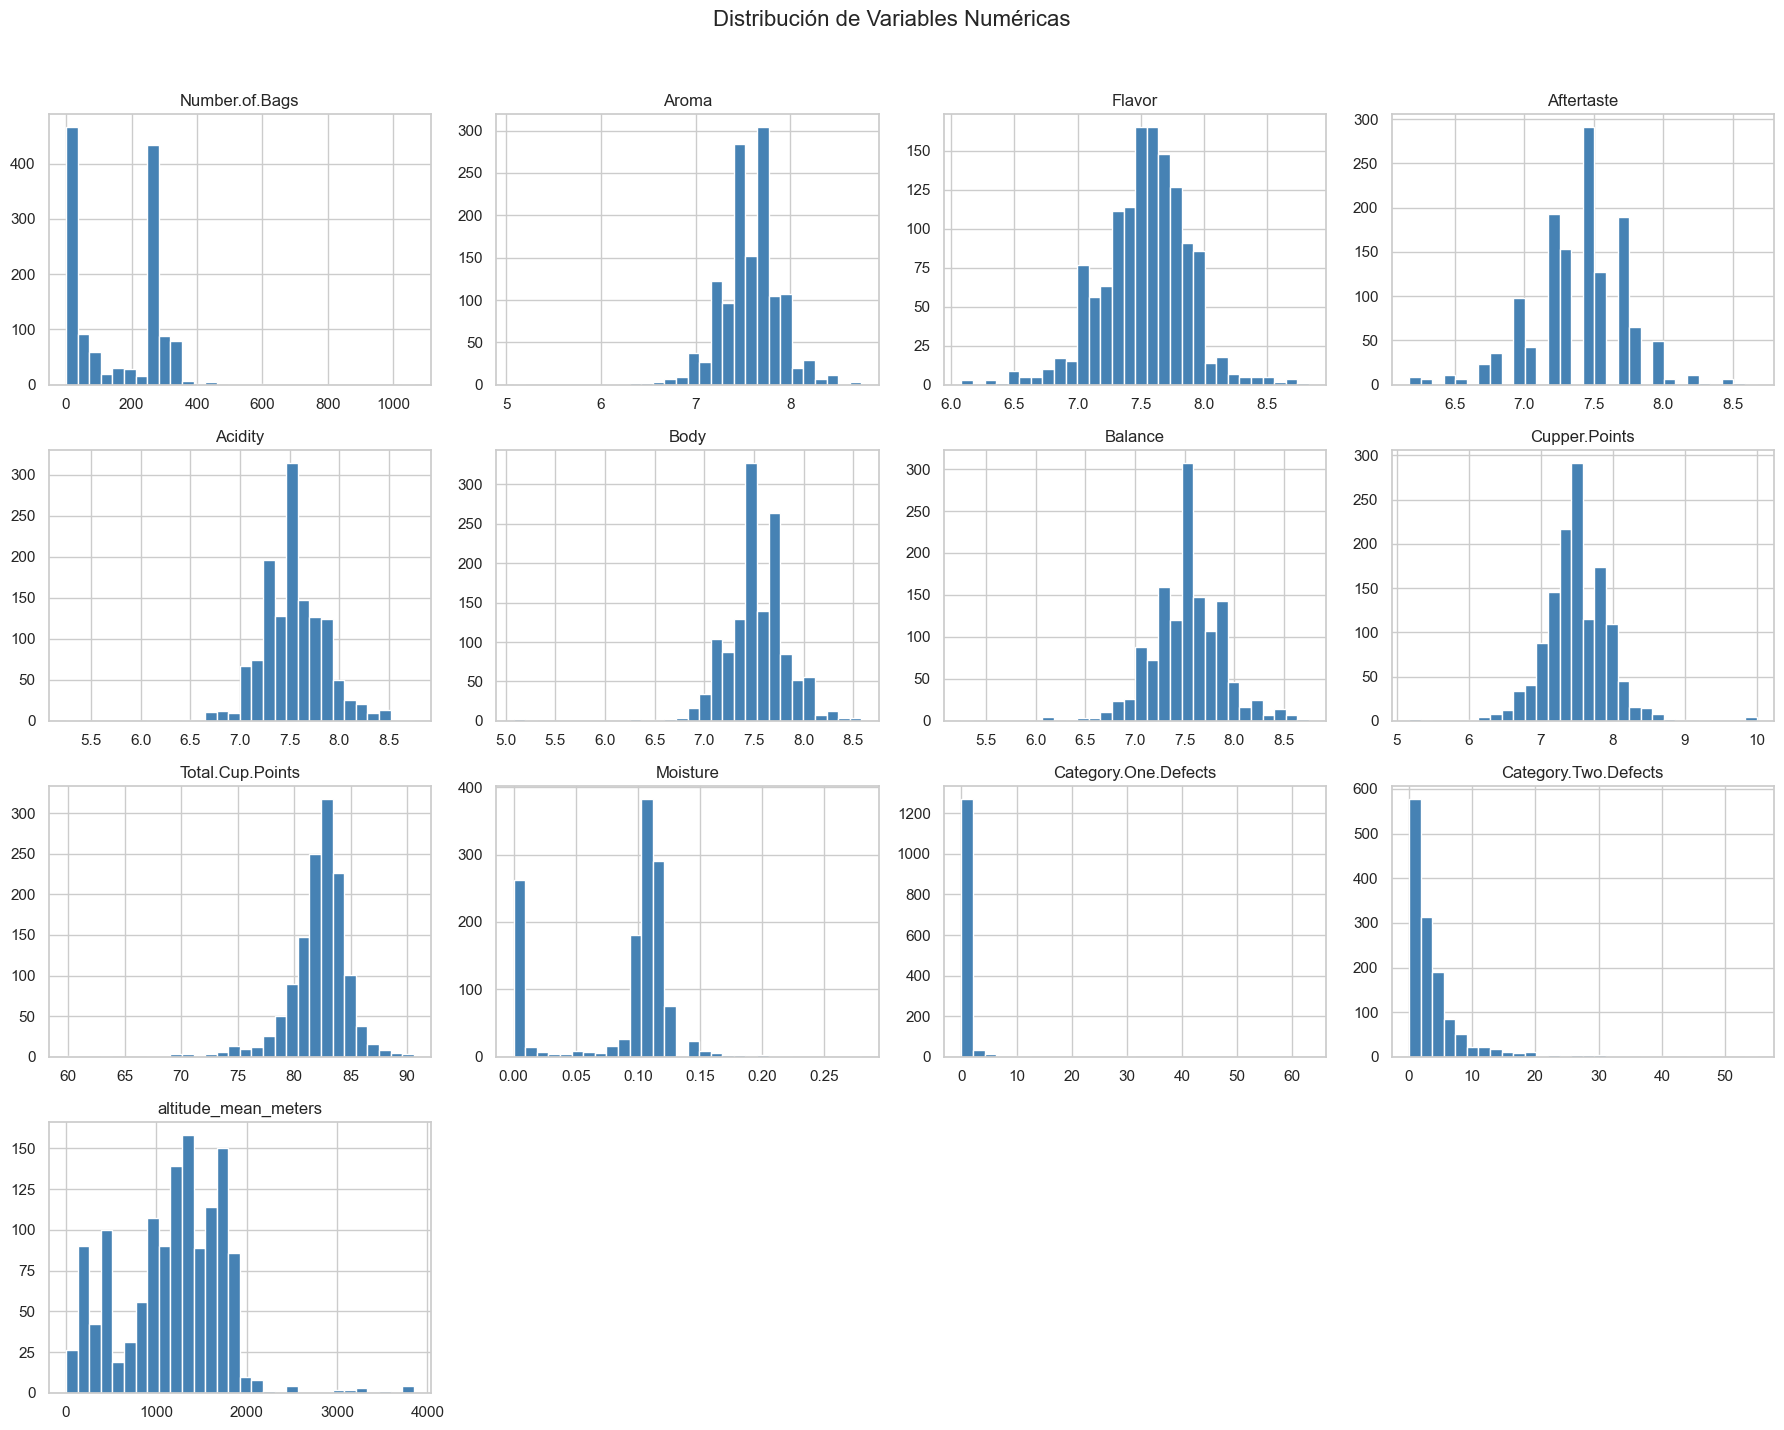

In [10]:
columnas_numericas = df.select_dtypes(include=np.number).columns.tolist()

df[columnas_numericas].hist(bins=30, figsize=(18, 14), color='steelblue', edgecolor='white')
plt.suptitle("Distribución de Variables Numéricas", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 10. Distribución del puntaje total

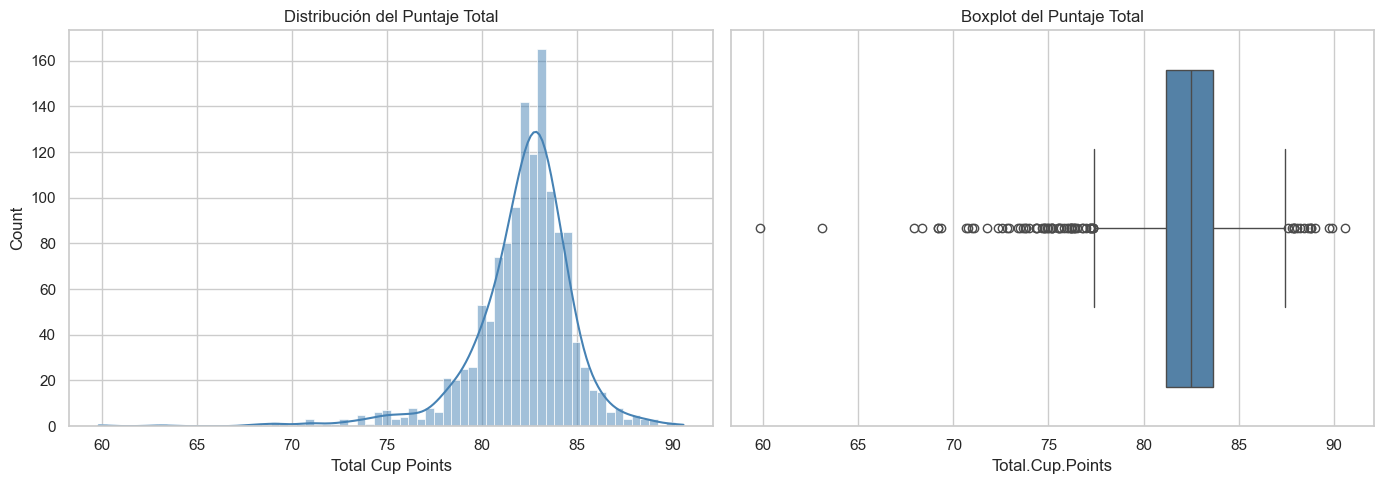

Media/Mean:    82.16
Mediana/Median:  82.50
Desvío estándar/Std: 2.69


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Total.Cup.Points'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Distribución del Puntaje Total")
axes[0].set_xlabel("Total Cup Points")

sns.boxplot(x=df['Total.Cup.Points'], ax=axes[1], color='steelblue')
axes[1].set_title("Boxplot del Puntaje Total")

plt.tight_layout()
plt.show()

print(f"Media/Mean:    {df['Total.Cup.Points'].mean():.2f}")
print(f"Mediana/Median:  {df['Total.Cup.Points'].median():.2f}")
print(f"Desvío estándar/Std: {df['Total.Cup.Points'].std():.2f}")

# 11. Detección de outliers en atributos sensoriales

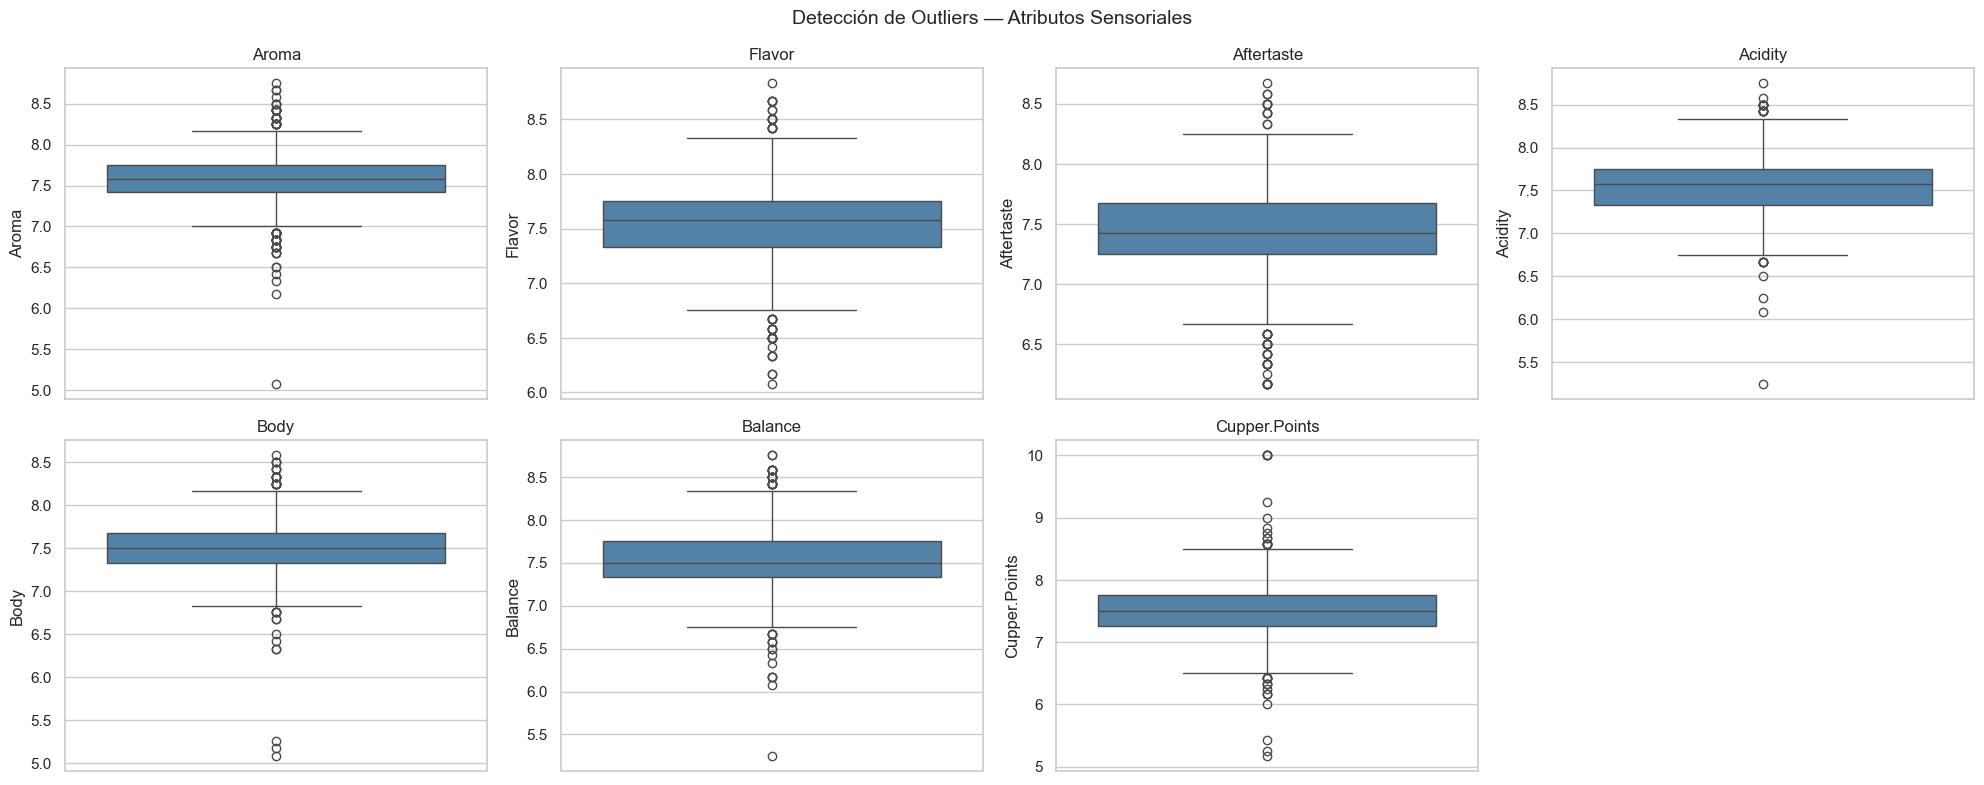

In [12]:
atributos_sensoriales = [
    'Aroma', 'Flavor', 'Aftertaste', 'Acidity',
    'Body', 'Balance', 'Cupper.Points'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8)) 
axes = axes.flatten()

for i, col in enumerate(atributos_sensoriales):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)
axes[7].set_visible(False)

plt.suptitle("Detección de Outliers — Atributos Sensoriales", fontsize=14)
plt.tight_layout()
plt.show()

Los atributos **Aroma, Flavor, Aftertaste, Acidity, Body y Balance** muestran un comportamiento similar: la mayoría de los cafés obtienen puntajes concentrados entre 7 y 8, con algunos outliers hacia abajo cercanos a 0 que corresponden a registros problemáticos o erróneos. Por otro lado, **Uniformity, Clean.Cup y Sweetness** tienen una distribución muy diferente y polarizada: casi todos los cafés alcanzan el puntaje máximo de 10, mientras que los pocos que no lo hacen caen a valores muy bajos, lo que sugiere que un café o tiene esta característica perfecta o directamente falla en ella. Finalmente, **Cupper.Points** se comporta de forma más dispersa y similar a los primeros seis atributos, aunque con mayor variabilidad.

# 12. Cantidad de cafés por país

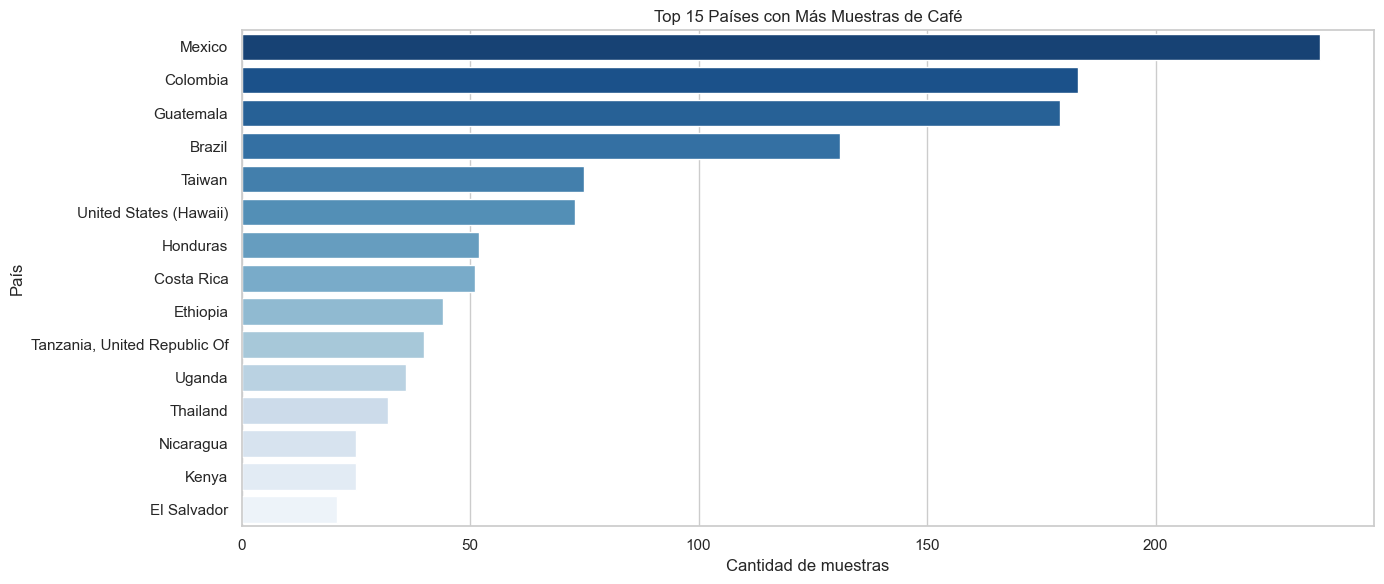

Country.of.Origin
Mexico                          236
Colombia                        183
Guatemala                       179
Brazil                          131
Taiwan                           75
United States (Hawaii)           73
Honduras                         52
Costa Rica                       51
Ethiopia                         44
Tanzania, United Republic Of     40
Uganda                           36
Thailand                         32
Nicaragua                        25
Kenya                            25
El Salvador                      21
Name: count, dtype: int64


In [13]:
top_paises = df['Country.of.Origin'].value_counts().head(15)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_paises.values, y=top_paises.index, hue=top_paises.index, palette='Blues_r', legend=False)
plt.title("Top 15 Países con Más Muestras de Café")
plt.xlabel("Cantidad de muestras")
plt.ylabel("País")
plt.tight_layout()
plt.show()

print(top_paises)

# 13a. Puntaje máximo por país

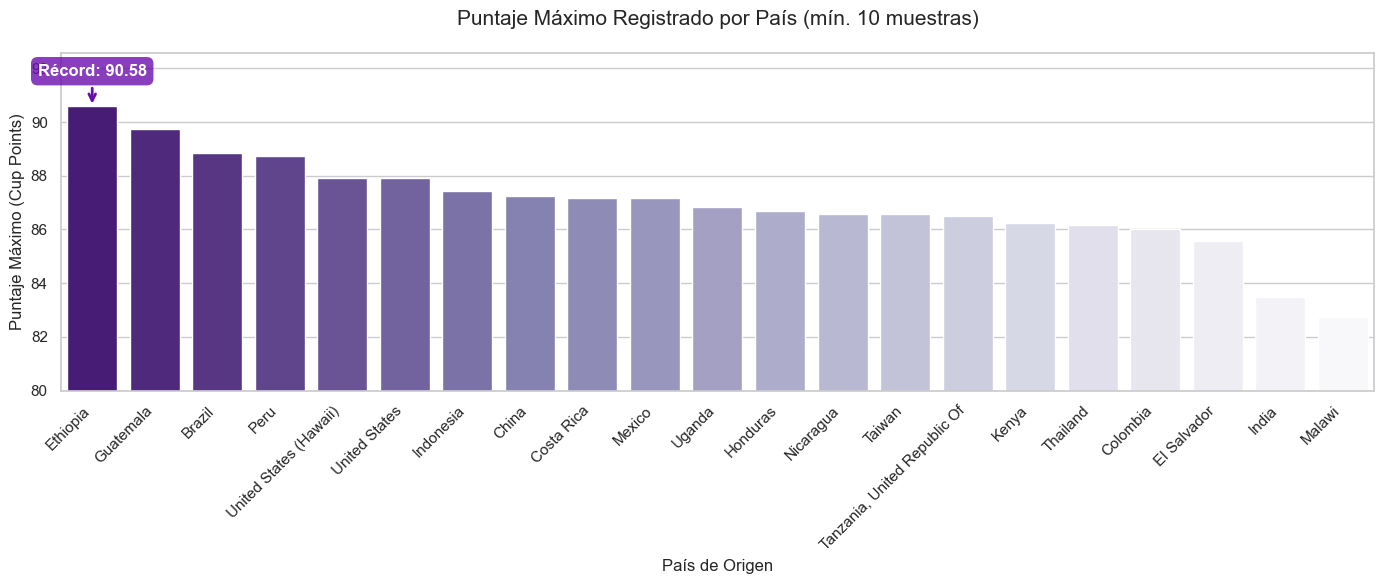

                        Muestras  Puntaje Máximo
Country.of.Origin                               
Ethiopia                      44           90.58
Guatemala                    179           89.75
Brazil                       131           88.83
Peru                          10           88.75
United States (Hawaii)        73           87.92
United States                 11           87.92
Indonesia                     20           87.42
China                         16           87.25
Costa Rica                    51           87.17
Mexico                       236           87.17


In [14]:
calidad_pais_max = (
    df.groupby('Country.of.Origin')['Total.Cup.Points']
    .agg(count='count', max_score='max') # Cambiamos mean por max
    .query('count >= 10')
    .rename(columns={'max_score': 'Puntaje Máximo', 'count': 'Muestras'})
    .sort_values('Puntaje Máximo', ascending=False)
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    x=calidad_pais_max.index,
    y=calidad_pais_max['Puntaje Máximo'],
    hue=calidad_pais_max.index,
    palette='Purples_r', 
    legend=False
)

pais_top = calidad_pais_max.index[0]
valor_top = calidad_pais_max['Puntaje Máximo'].iloc[0]

ax.annotate(
    f'Récord: {valor_top:.2f}', 
    xy=(0, valor_top), 
    xytext=(0, 20),
    textcoords="offset points",
    ha='center', va='bottom',
    fontsize=12, fontweight='bold',
    color='white',
    bbox=dict(boxstyle="round,pad=0.4", fc="#6a0dad", ec="none", alpha=0.8),
    arrowprops=dict(arrowstyle="->", color='#6a0dad', lw=2)
)

plt.title("Puntaje Máximo Registrado por País (mín. 10 muestras)", fontsize=15, pad=20)
plt.xlabel("País de Origen", fontsize=12)
plt.ylabel("Puntaje Máximo (Cup Points)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(80, valor_top + 2) 

plt.tight_layout()
plt.show()
print(calidad_pais_max.head(10))

# 13b. Puntaje promedio por país

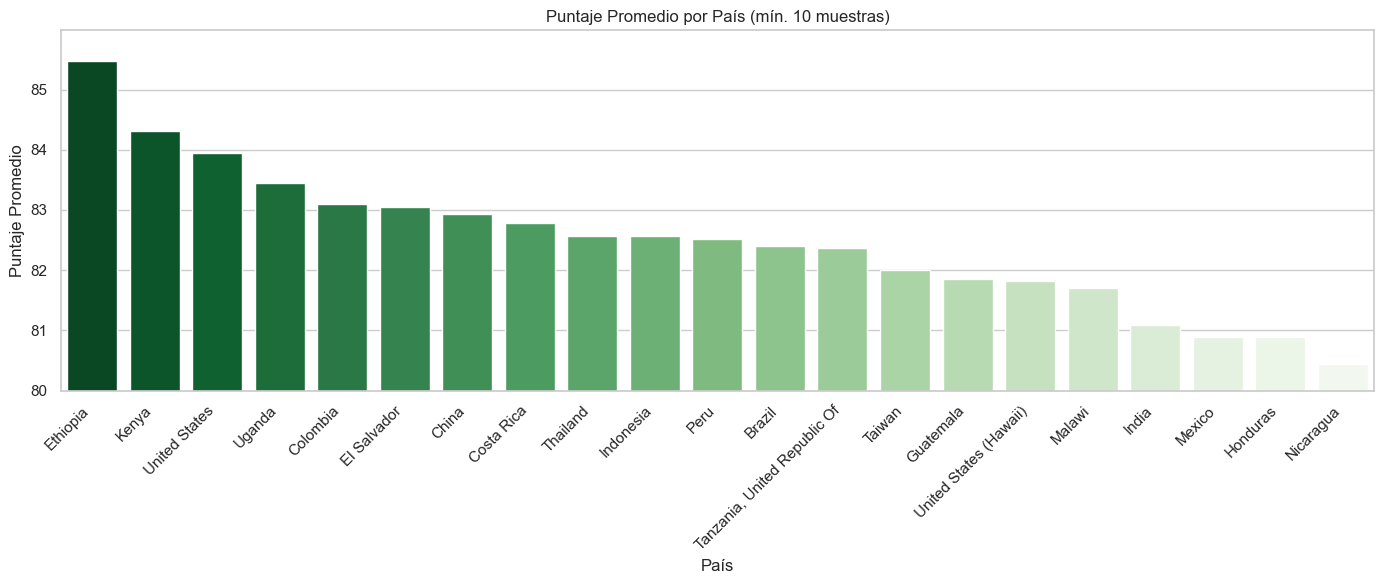

,Muestras,Puntaje Promedio
Country.of.Origin,,
Ethiopia,44,85.484091
Kenya,25,84.309600
United States,11,83.946364
Uganda,36,83.451944
Colombia,183,83.106557
El Salvador,21,83.052857
China,16,82.927500
Costa Rica,51,82.789020
Thailand,32,82.573750


In [15]:
# Paso 1: Crear calidad_pais
calidad_pais = (
    df.groupby('Country.of.Origin')['Total.Cup.Points']
    .agg(count='count', mean='mean')
    .query('count >= 10')
    .rename(columns={'mean': 'Puntaje Promedio', 'count': 'Muestras'})
    .sort_values('Puntaje Promedio', ascending=False)
)

# Paso 2: Graficar
plt.figure(figsize=(14, 6))
sns.barplot(
    x=calidad_pais.index,
    y=calidad_pais['Puntaje Promedio'],
    hue=calidad_pais.index,
    palette='Greens_r',
    legend=False
)
plt.title("Puntaje Promedio por País (mín. 10 muestras)")
plt.xlabel("País")
plt.ylabel("Puntaje Promedio")
plt.xticks(rotation=45, ha='right')
plt.ylim(80, calidad_pais['Puntaje Promedio'].max() + 0.5)
plt.tight_layout()
plt.show()

calidad_pais

# 14. Altura de Producción del Top 10 de Países por Puntaje

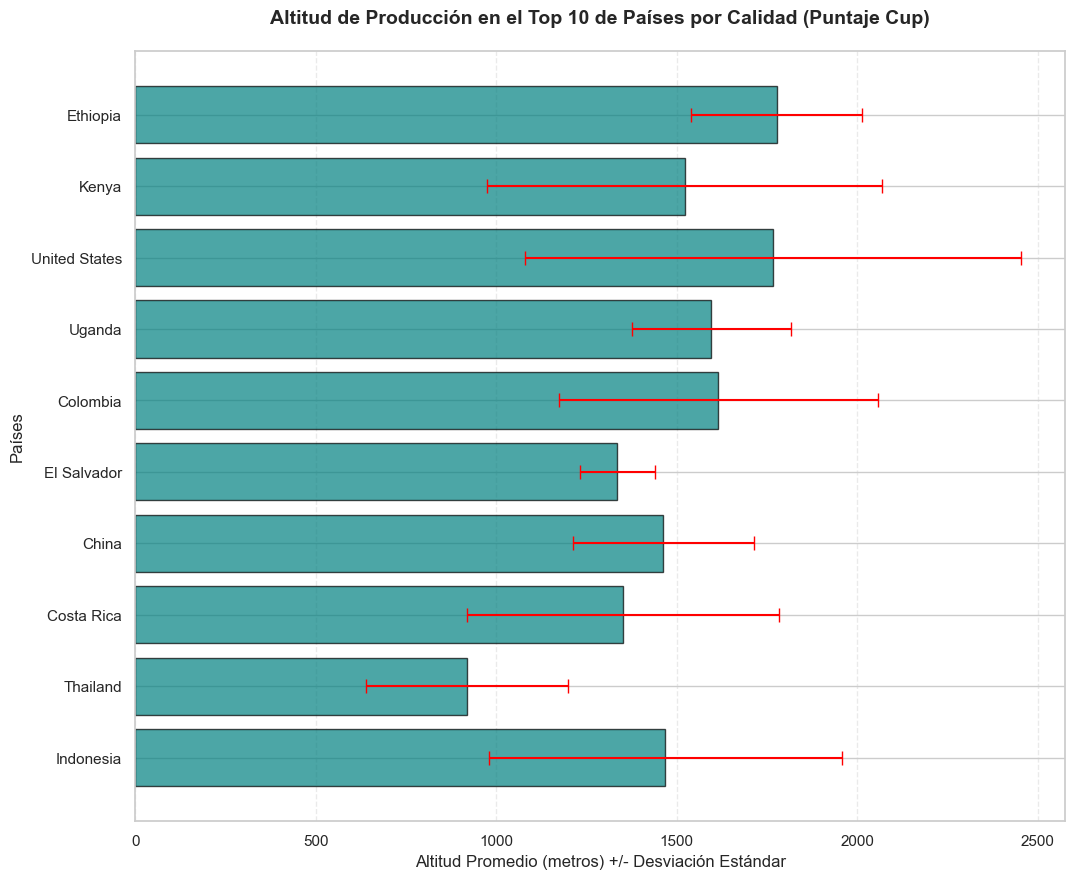

In [71]:
counts = df['Country.of.Origin'].value_counts()
paises_con_data = counts[counts > 5].index
df_filt = df[df['Country.of.Origin'].isin(paises_con_data)]

top_10_stats = df_filt.groupby('Country.of.Origin').agg({
    'Total.Cup.Points': 'mean',
    'altitude_mean_meters': ['mean', 'std']
}).sort_values(by=('Total.Cup.Points', 'mean'), ascending=False).head(10)

top_10_stats.columns = ['score_mean', 'alt_mean', 'alt_std']
top_10_stats = top_10_stats.iloc[::-1]

fig, ax = plt.subplots(figsize=(12, 10)) 

bars = ax.barh(
    top_10_stats.index, 
    top_10_stats['alt_mean'], 
    xerr=top_10_stats['alt_std'],
    color='teal', 
    alpha=0.7,
    edgecolor='black',
    capsize=5,
    error_kw={'ecolor': 'red', 'linewidth': 1.5} 
)
ax.set_title('Altitud de Producción en el Top 10 de Países por Calidad (Puntaje Cup)', fontsize=14, pad=20, weight='bold')
ax.set_xlabel('Altitud Promedio (metros) +/- Desviación Estándar', fontsize=12)
ax.set_ylabel('Países', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.4)

# 15. Puntaje promedio por método de procesamiento

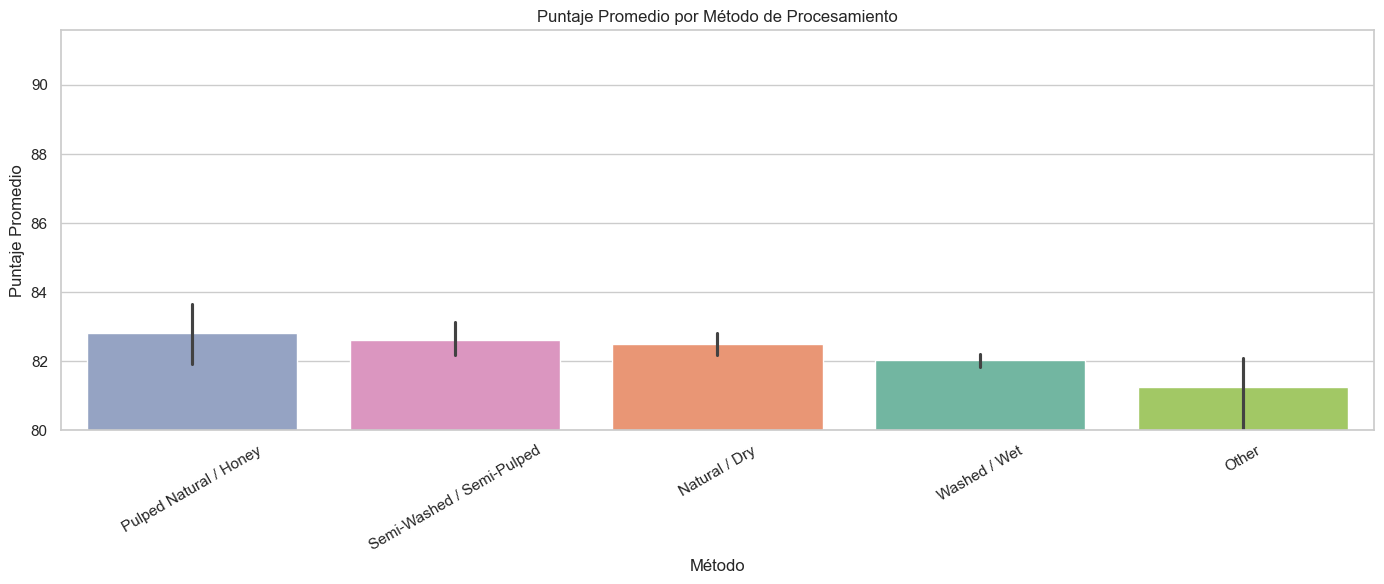

                           Puntaje_Medio  Cantidad_Muestras  Desv_Estandar
Processing.Method                                                         
Pulped Natural / Honey             82.81                 14           1.69
Semi-Washed / Semi-Pulped          82.63                 55           1.78
Natural / Dry                      82.50                320           2.83
Washed / Wet                       82.03                904           2.65
Other                              81.27                 39           3.37


In [49]:
orden = (
    df.groupby('Processing.Method')['Total.Cup.Points']
    .mean()
    .sort_values(ascending=False)
    .index
)
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df,
    x='Processing.Method',
    y='Total.Cup.Points',
    hue='Processing.Method',
    palette='Set2',
    legend=False,
    order=orden
)
plt.xticks(rotation=30)
plt.title("Puntaje Promedio por Método de Procesamiento")
plt.xlabel("Método")
plt.ylabel("Puntaje Promedio")
plt.ylim(80, df['Total.Cup.Points'].max() + 1)
plt.tight_layout()
plt.show()

stats_procesamiento = df.groupby('Processing.Method').agg({
    'Total.Cup.Points': ['mean', 'count', 'std']
}).sort_values(by=('Total.Cup.Points', 'mean'), ascending=False).round(2)

stats_procesamiento.columns = ['Puntaje_Medio', 'Cantidad_Muestras', 'Desv_Estandar']
print(stats_procesamiento)

Los palitos negros sobre cada barra representan el intervalo de confianza del promedio. Barras con palitos cortos indican que hay muchas muestras y el promedio es confiable, mientras que palitos largos indican pocas muestras y mayor incertidumbre en el valor promedio.

# 16. Matriz de correlación

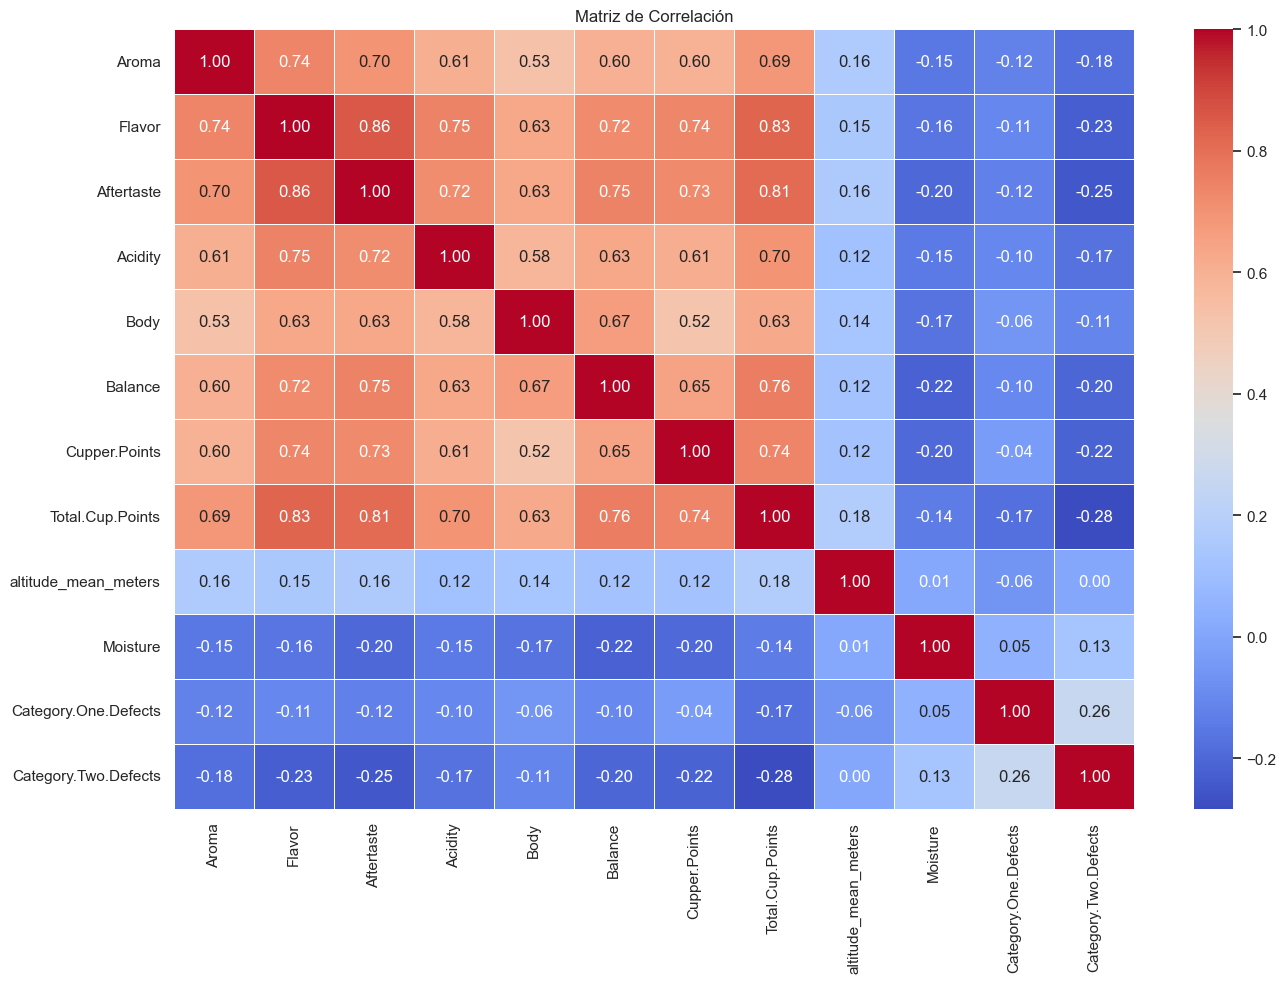

In [18]:
columnas_corr = [
    'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body',
    'Balance', 'Cupper.Points', 'Total.Cup.Points', 'altitude_mean_meters',
    'Moisture', 'Category.One.Defects', 'Category.Two.Defects', 
]

corr = df[columnas_corr].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

Los atributos sensoriales Flavor, Aftertaste, Acidity y Balance están fuertemente correlacionados entre sí, con valores entre 0.70 y 0.90, lo que indica que un café con buen sabor tiende también a tener buen retrogusto, acidez y balance. En cuanto al puntaje total, Flavor es el atributo que más lo determina con una correlación de 0.87, seguido de Aftertaste y Balance. Por otro lado, altitude_mean_meters muestra correlación cercana a 0 con todas las variables, lo que indica que la altitud por sí sola no explica la calidad del café. Finalmente, Category.One.Defects y Category.Two.Defects tienen correlación negativa con el puntaje total, confirmando que a mayor cantidad de defectos, menor es la calidad final del café.

# 17. Variables más correlacionadas con el puntaje total

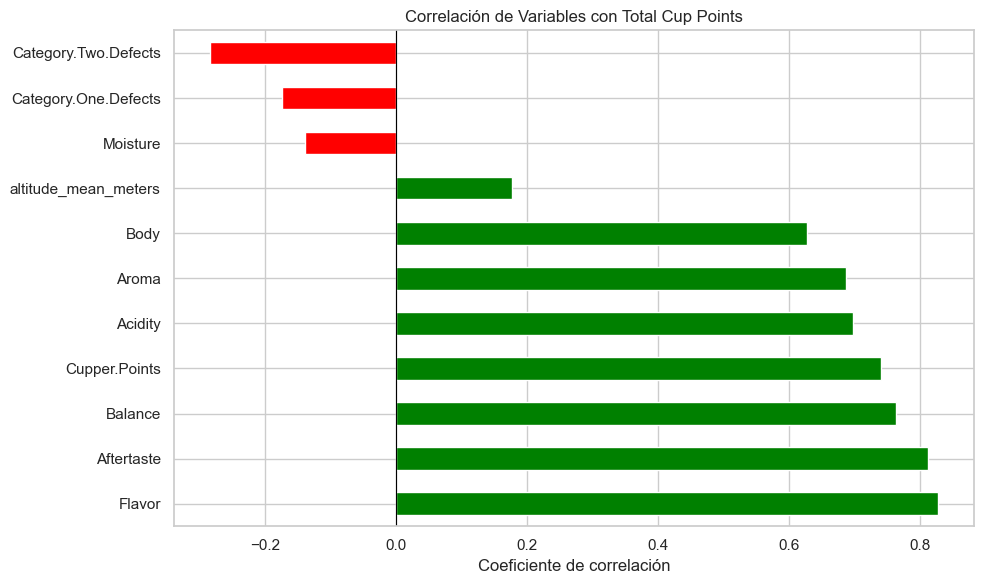

Flavor                  0.826833
Aftertaste              0.812532
Balance                 0.762988
Cupper.Points           0.740615
Acidity                 0.696983
Aroma                   0.686801
Body                    0.627959
altitude_mean_meters    0.177116
Moisture               -0.139691
Category.One.Defects   -0.174179
Category.Two.Defects   -0.283802
Name: Total.Cup.Points, dtype: float64


In [19]:
correlacion_puntaje = corr['Total.Cup.Points'].drop('Total.Cup.Points').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
correlacion_puntaje.plot(kind='barh', color=['green' if v > 0 else 'red' for v in correlacion_puntaje])
plt.title("Correlación de Variables con Total Cup Points")
plt.xlabel("Coeficiente de correlación")
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(correlacion_puntaje)

# 18. Pairplot de atributos sensoriales

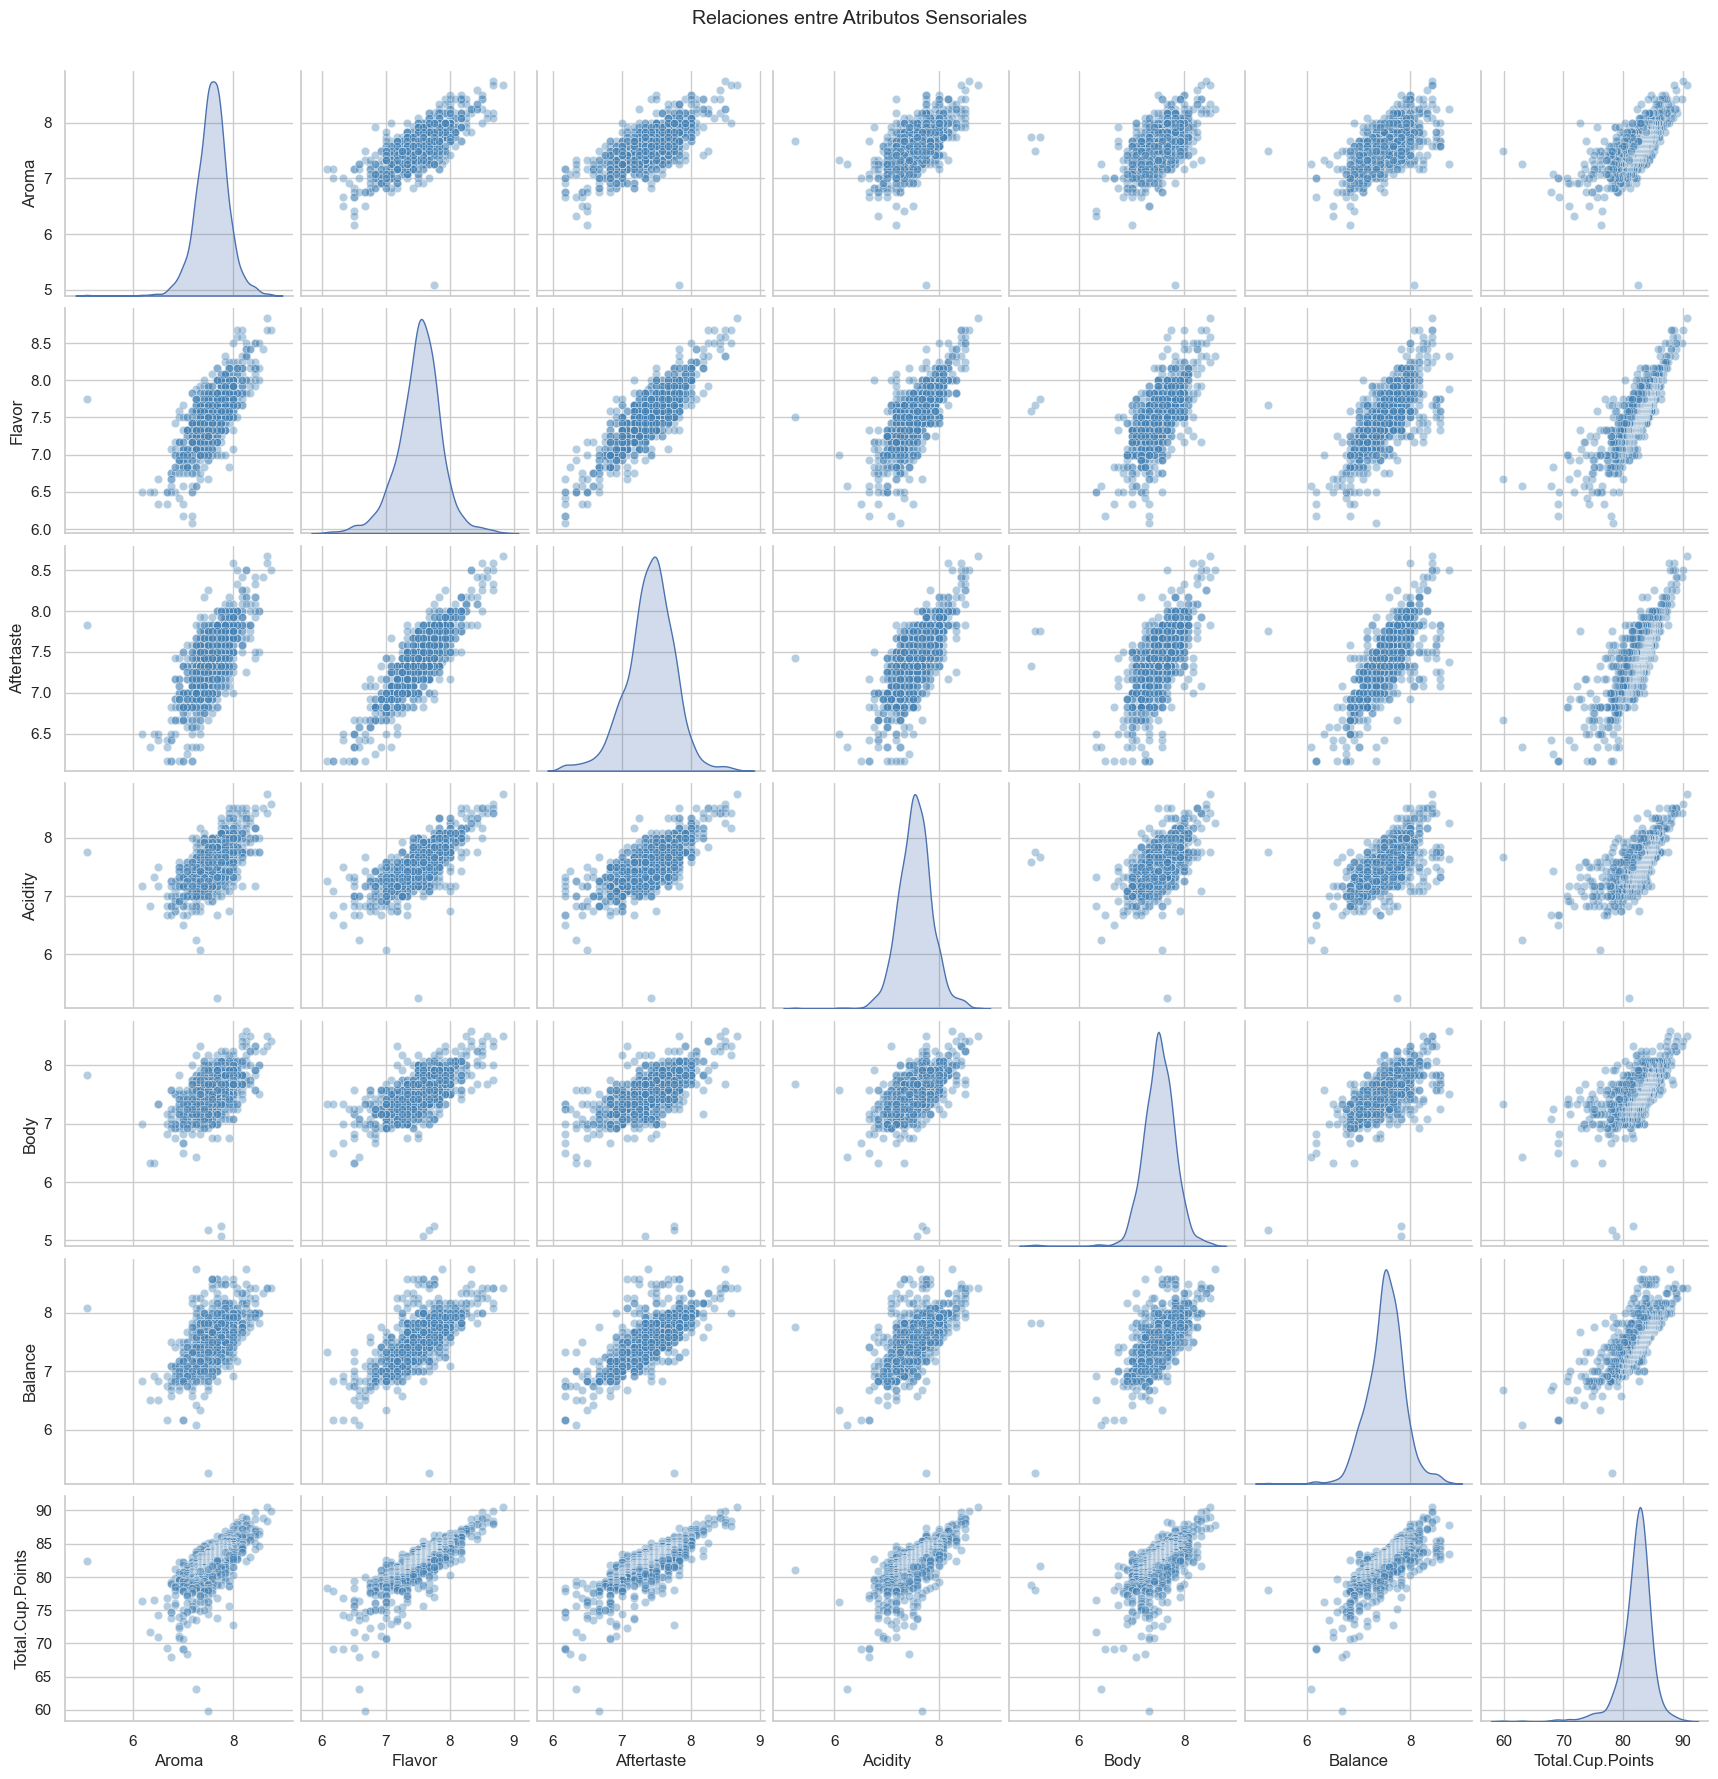

In [20]:
sns.pairplot(
    df[['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Total.Cup.Points']],
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 'color': 'steelblue'}
)
plt.suptitle("Relaciones entre Atributos Sensoriales", y=1.02, fontsize=14)
plt.show()

El pairplot muestra la relación entre cada par de atributos sensoriales en una grilla de gráficos. En la diagonal se puede ver la distribución de cada variable individualmente, mientras que en el resto de las celdas se visualiza la relación entre dos variables: si los puntos forman una tendencia hacia arriba, significa que ambas variables crecen juntas. Este gráfico complementa la matriz de correlación, ya que no solo muestra si dos variables están relacionadas numéricamente, sino también cómo es visualmente esa relación.

# 19a. Relación entre altitud y calidad

Coeficiente de Correlación de Pearson (r): 0.2056


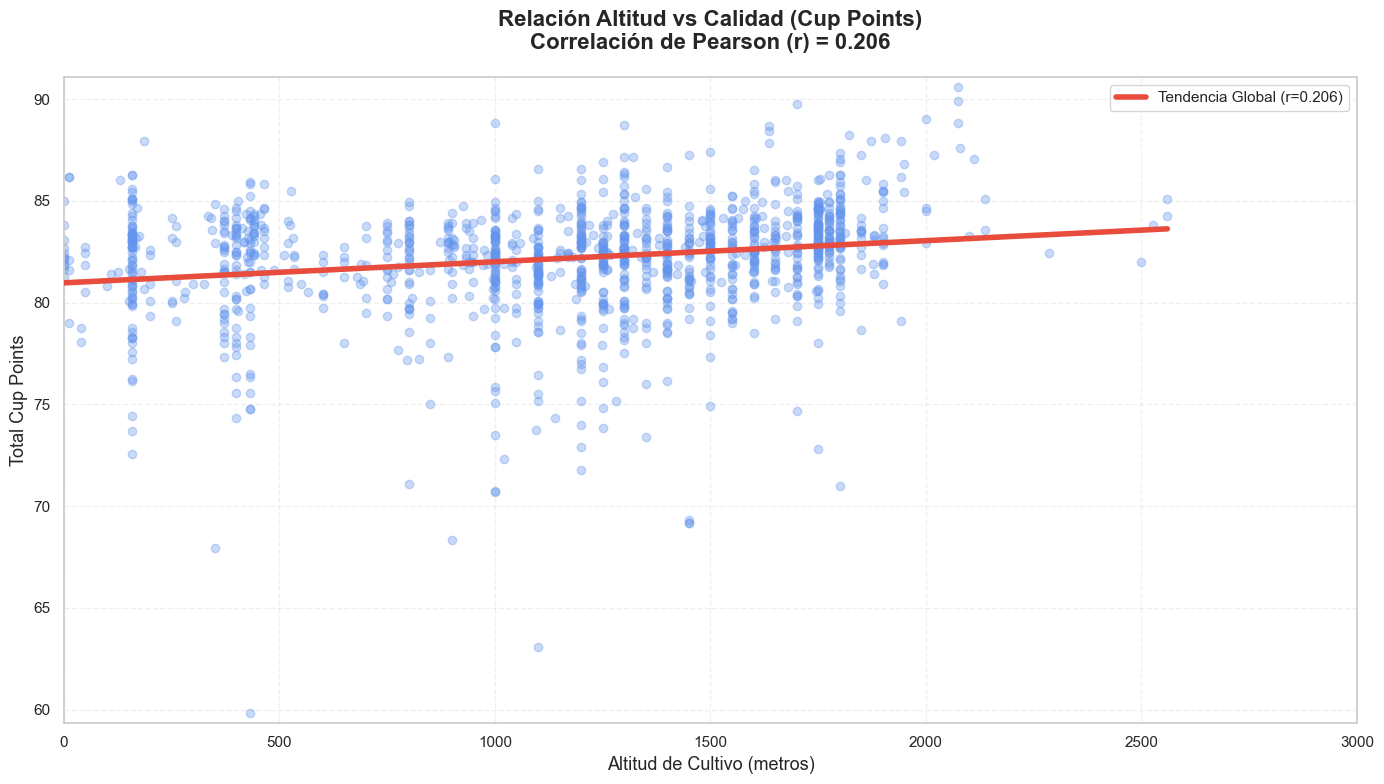

In [55]:
df_analisis = df.dropna(subset=['altitude_mean_meters', 'Total.Cup.Points'])
df_analisis = df_analisis[df_analisis['altitude_mean_meters'] < 3000]

correlacion_r = df_analisis['altitude_mean_meters'].corr(df_analisis['Total.Cup.Points'])
print(f"Coeficiente de Correlación de Pearson (r): {correlacion_r:.4f}")

m, b = np.polyfit(df_analisis['altitude_mean_meters'], df_analisis['Total.Cup.Points'], 1)

x_linea = np.linspace(df_analisis['altitude_mean_meters'].min(), df_analisis['altitude_mean_meters'].max(), 100)
y_linea = m * x_linea + b


plt.figure(figsize=(14, 8))

plt.scatter(
    df_analisis['altitude_mean_meters'], 
    df_analisis['Total.Cup.Points'], 
    color='cornflowerblue',
    alpha=0.35, 
    edgecolor=None,
    zorder=1 
)


plt.plot(
    x_linea, y_linea, 
    color='#e74c3c',
    linestyle='-', linewidth=4, 
    label=f'Tendencia Global (r={correlacion_r:.3f})',
    zorder=10
)


plt.title(
    f"Relación Altitud vs Calidad (Cup Points)\nCorrelación de Pearson (r) = {correlacion_r:.3f}", 
    fontsize=16, weight='bold', pad=20
)
plt.xlabel("Altitud de Cultivo (metros)", fontsize=13)
plt.ylabel("Total Cup Points", fontsize=13)
plt.xlim(0, 3000)
plt.ylim(df_analisis['Total.Cup.Points'].min() - 0.5, df_analisis['Total.Cup.Points'].max() + 0.5) 
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3) 
plt.tight_layout()
plt.show()

# 19b. Puntaje Promedio por Rango de Altitud

In [56]:
df['rango_altitud'] = pd.cut(
    df['altitude_mean_meters'],
    bins=[0, 500, 1000, 1500, 2000, 3000],
    labels=['0-500m', '500-1000m', '1000-1500m', '1500-2000m', '2000-3000m']
)

resumen_altitud = (
    df.groupby('rango_altitud', observed=True)['Total.Cup.Points']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Puntaje Promedio', 'count': 'Muestras'})
    .round(2)
)

resumen_altitud

,Puntaje Promedio,Muestras
rango_altitud,,
0-500m,81.72,257
500-1000m,81.65,211
1000-1500m,81.78,477
1500-2000m,83.14,361
2000-3000m,85.18,16


# 19c. Altitud promedio por país

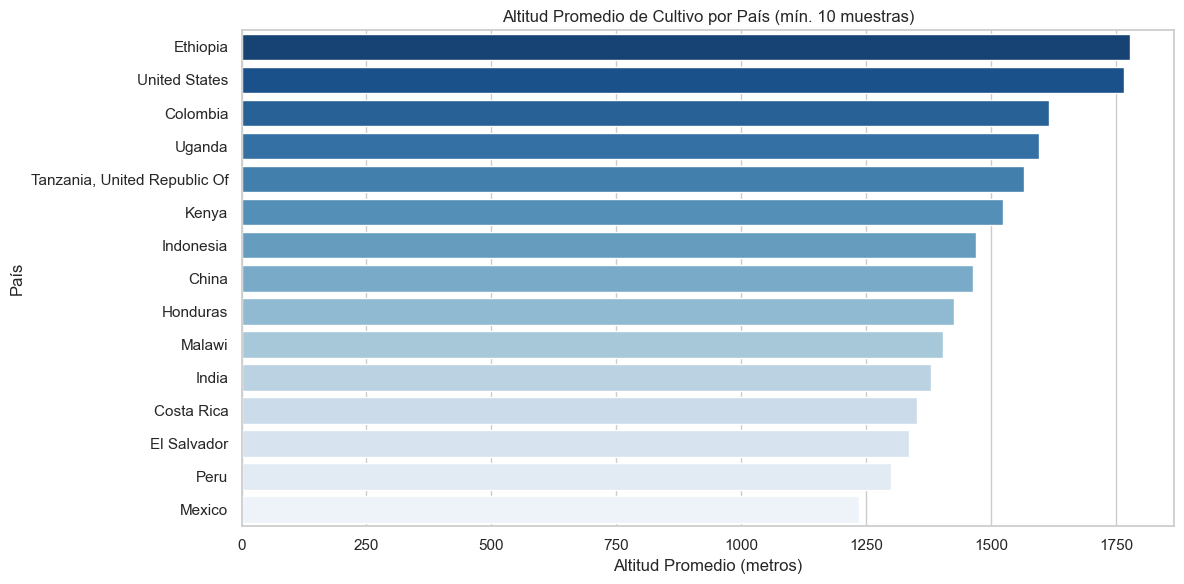

,Altitud Promedio,Muestras
Country.of.Origin,,
Ethiopia,1776.61,44
United States,1765.84,11
Colombia,1615.28,183
Uganda,1595.50,36
"Tanzania, United Republic Of",1565.52,40
Kenya,1522.48,25
Indonesia,1468.75,20
China,1463.12,16
Honduras,1424.92,52


In [57]:
altitud_pais = (
    df.groupby('Country.of.Origin')['altitude_mean_meters']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Altitud Promedio', 'count': 'Muestras'})
    .query('Muestras >= 10')
    .sort_values('Altitud Promedio', ascending=False)
    .head(15)
    .round(2)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=altitud_pais['Altitud Promedio'],
    y=altitud_pais.index,
    hue=altitud_pais.index,
    palette='Blues_r',
    legend=False,
    errorbar=None
)
plt.title("Altitud Promedio de Cultivo por País (mín. 10 muestras)")
plt.xlabel("Altitud Promedio (metros)")
plt.ylabel("País")
plt.tight_layout()
plt.show()

altitud_pais

# 19d. Altitud vs defectos:

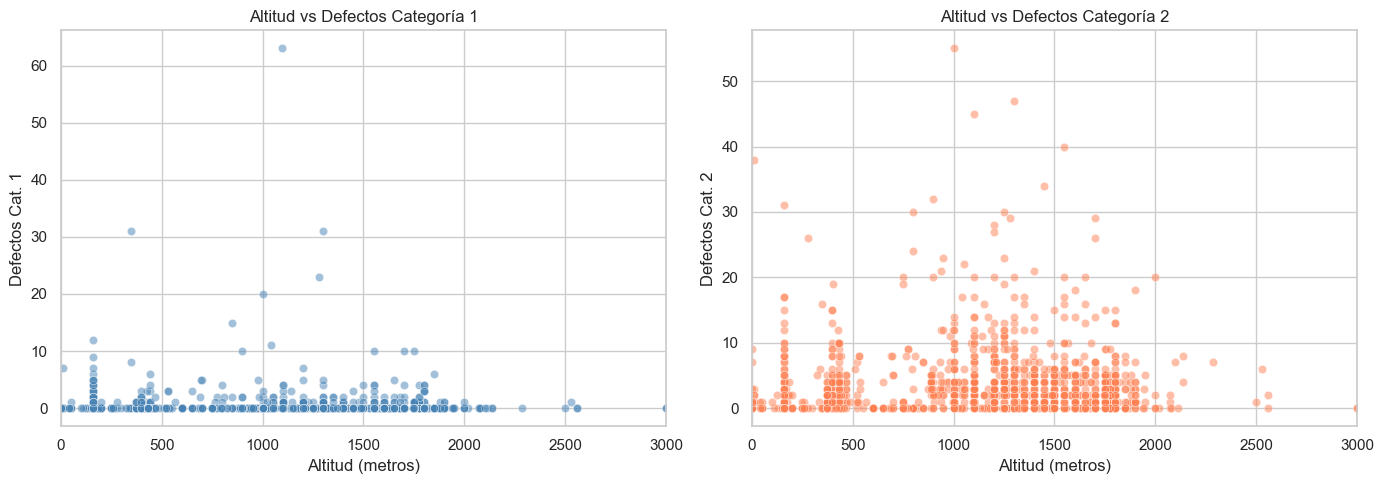

Correlación Altitud vs Defectos Cat.1: -0.06
Correlación Altitud vs Defectos Cat.2: 0.00


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x='altitude_mean_meters',
    y='Category.One.Defects',
    alpha=0.5,
    color='steelblue',
    ax=axes[0]
)
axes[0].set_title("Altitud vs Defectos Categoría 1")
axes[0].set_xlabel("Altitud (metros)")
axes[0].set_ylabel("Defectos Cat. 1")
axes[0].set_xlim(0, 3000)

sns.scatterplot(
    data=df,
    x='altitude_mean_meters',
    y='Category.Two.Defects',
    alpha=0.5,
    color='coral',
    ax=axes[1]
)
axes[1].set_title("Altitud vs Defectos Categoría 2")
axes[1].set_xlabel("Altitud (metros)")
axes[1].set_ylabel("Defectos Cat. 2")
axes[1].set_xlim(0, 3000)

plt.tight_layout()
plt.show()

print(f"Correlación Altitud vs Defectos Cat.1: {df['altitude_mean_meters'].corr(df['Category.One.Defects']):.2f}")
print(f"Correlación Altitud vs Defectos Cat.2: {df['altitude_mean_meters'].corr(df['Category.Two.Defects']):.2f}")

# 19e. Altitud promedio por variedad

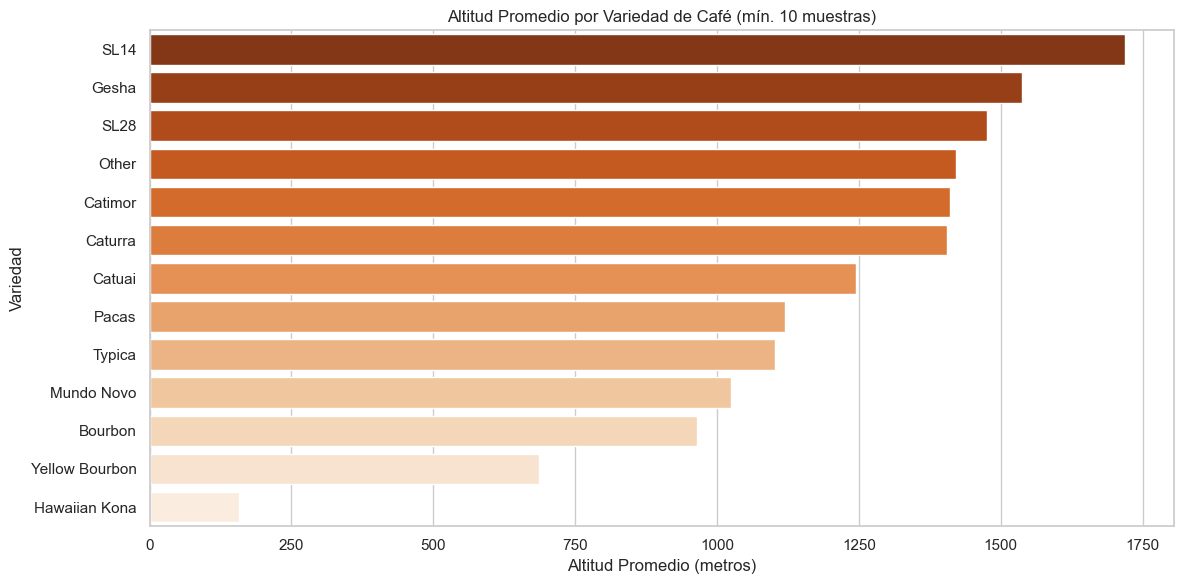

,Altitud Promedio,Muestras
Variety,,
SL14,1719.44,18
Gesha,1537.96,12
SL28,1475.18,17
Other,1421.89,174
Catimor,1410.50,20
Caturra,1404.97,342
Catuai,1244.48,72
Pacas,1119.85,13
Typica,1101.85,224


In [59]:
altitud_variedad = (
    df.groupby('Variety')['altitude_mean_meters']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Altitud Promedio', 'count': 'Muestras'})
    .query('Muestras >= 10')
    .sort_values('Altitud Promedio', ascending=False)
    .head(15)
    .round(2)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=altitud_variedad['Altitud Promedio'],
    y=altitud_variedad.index,
    hue=altitud_variedad.index,
    palette='Oranges_r',
    legend=False,
    errorbar=None
)
plt.title("Altitud Promedio por Variedad de Café (mín. 10 muestras)")
plt.xlabel("Altitud Promedio (metros)")
plt.ylabel("Variedad")
plt.tight_layout()
plt.show()

altitud_variedad

# 20. Top 10 mejores cafés

In [26]:
top10 = (
    df[['Species', 'Country.of.Origin', 'Variety', 'Processing.Method',
        'altitude_mean_meters', 'Total.Cup.Points']]
    .sort_values('Total.Cup.Points', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10.index += 1
top10

,Species,Country.of.Origin,Variety,Processing.Method,altitude_mean_meters,Total.Cup.Points
1,Arabica,Ethiopia,Other,Washed / Wet,2075.0,90.58
2,Arabica,Ethiopia,Other,Washed / Wet,2075.0,89.92
3,Arabica,Guatemala,Bourbon,Washed / Wet,1700.0,89.75
4,Arabica,Ethiopia,Other,Natural / Dry,2000.0,89.00
5,Arabica,Brazil,Bourbon,Natural / Dry,1000.0,88.83
6,Arabica,Ethiopia,Other,Washed / Wet,2075.0,88.83
7,Arabica,Peru,Other,Washed / Wet,1300.0,88.75
8,Arabica,Ethiopia,Other,Natural / Dry,1635.0,88.67
9,Arabica,Ethiopia,Other,Natural / Dry,1635.0,88.42
10,Arabica,Ethiopia,Other,Natural / Dry,1822.5,88.25


# 21. Top 10 países con mayor calidad promedio

In [27]:
top_calidad = (
    df.groupby('Country.of.Origin')['Total.Cup.Points']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Puntaje Promedio', 'count': 'Muestras'})
    .query('Muestras >= 10')
    .sort_values('Puntaje Promedio', ascending=False)
    .head(10)
    .round(2)
)

top_calidad

,Puntaje Promedio,Muestras
Country.of.Origin,,
Ethiopia,85.48,44
Kenya,84.31,25
United States,83.95,11
Uganda,83.45,36
Colombia,83.11,183
El Salvador,83.05,21
China,82.93,16
Costa Rica,82.79,51
Thailand,82.57,32


# 22. Distribución de métodos de procesamiento

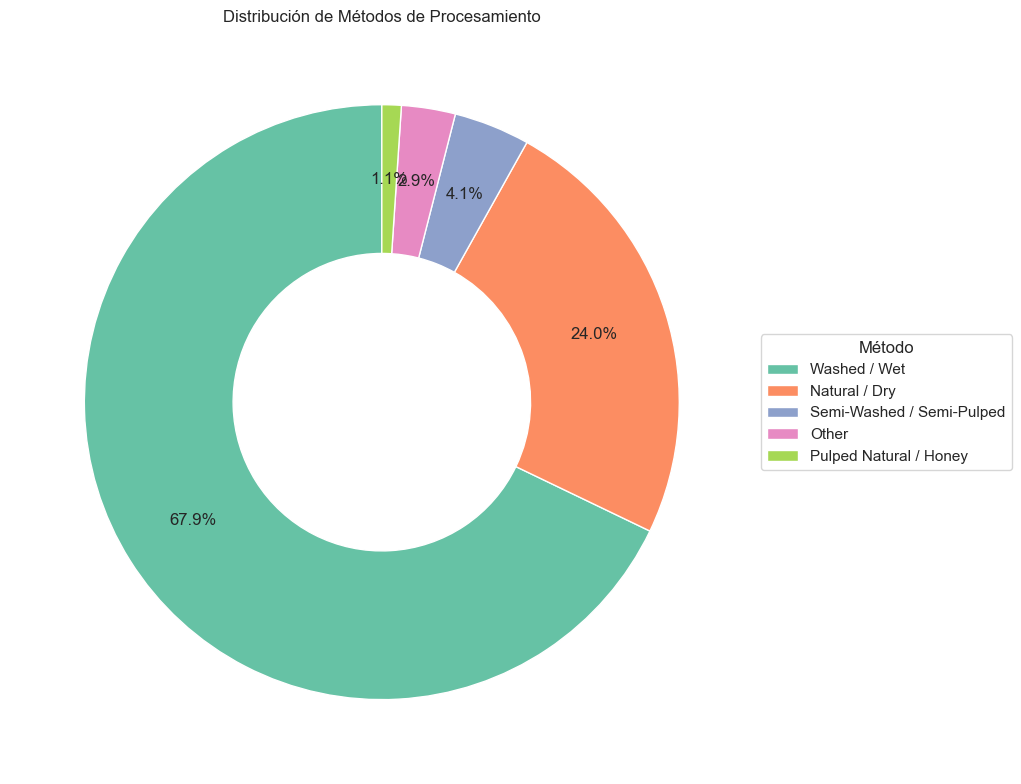

,Cantidad
Processing.Method,
Washed / Wet,904
Natural / Dry,320
Semi-Washed / Semi-Pulped,55
Other,39
Pulped Natural / Honey,14


In [28]:
conteo = df['Processing.Method'].value_counts()

plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    conteo.values,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2', len(conteo)),
    wedgeprops=dict(width=0.5),
    pctdistance=0.75
)

plt.legend(
    wedges,
    conteo.index,
    title="Método",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)
plt.title("Distribución de Métodos de Procesamiento")
plt.tight_layout()
plt.show()

conteo.to_frame(name='Cantidad')

# 23. Impacto del Método de Procesamiento en la Calidad

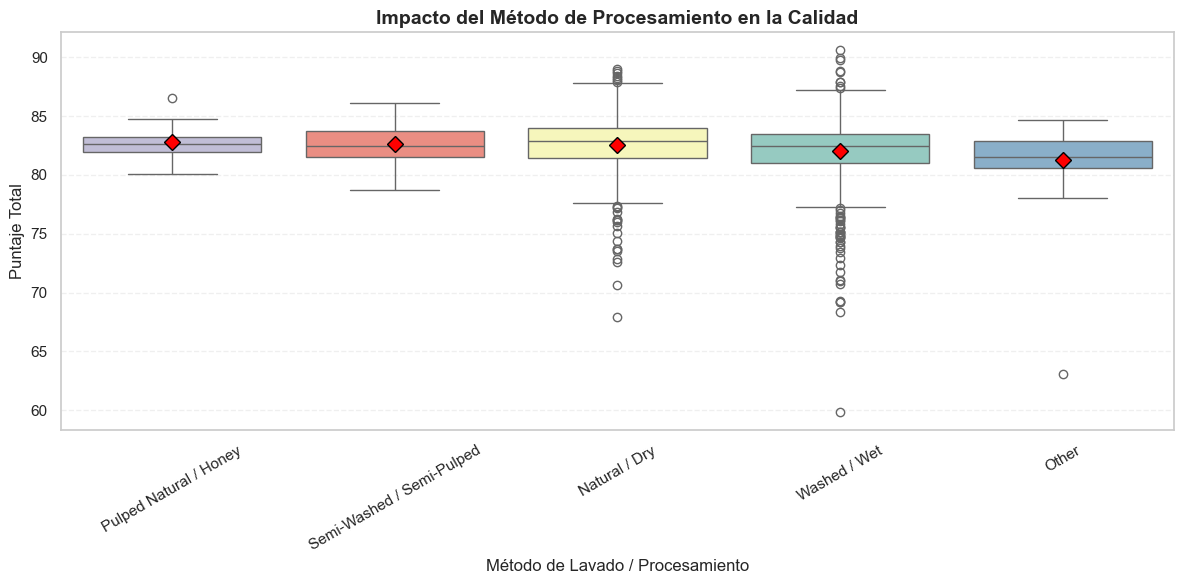

In [69]:
orden_metodos = df.groupby('Processing.Method')['Total.Cup.Points'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df, 
    x='Processing.Method', 
    y='Total.Cup.Points', 
    hue='Processing.Method', 
    order=orden_metodos,
    palette='Set3',         
    legend=False,            
    showmeans=True,
    meanprops={"marker":"D","markerfacecolor":"red", "markeredgecolor":"black", "markersize":"8"}
)

plt.xticks(rotation=30)
plt.title("Impacto del Método de Procesamiento en la Calidad", fontsize=14, weight='bold')
plt.ylabel("Puntaje Total")
plt.xlabel("Método de Lavado / Procesamiento")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 24. Resumen estadístico por país

In [29]:
resumen_pais = (
    df.groupby('Country.of.Origin')['Total.Cup.Points']
    .describe()
    .round(2)
    .sort_values('mean', ascending=False)
)

resumen_pais.head(15)

,count,mean,std,min,25%,50%,75%,max
Country.of.Origin,,,,,,,,
Papua New Guinea,1.0,85.75,NaN,85.75,85.75,85.75,85.75,85.75
Ethiopia,44.0,85.48,2.34,80.00,84.06,85.20,87.12,90.58
Japan,1.0,84.67,NaN,84.67,84.67,84.67,84.67,84.67
Kenya,25.0,84.31,1.46,79.83,84.00,84.58,85.00,86.25
United States,11.0,83.95,4.13,77.17,80.20,86.17,87.42,87.92
Panama,4.0,83.71,2.41,80.75,82.25,84.12,85.58,85.83
Uganda,36.0,83.45,1.61,80.50,82.65,83.21,84.54,86.83
Colombia,183.0,83.11,1.41,72.83,82.62,83.25,83.92,86.00
El Salvador,21.0,83.05,1.60,79.67,82.25,82.83,84.17,85.58


# 25. Análisis de variedades de café

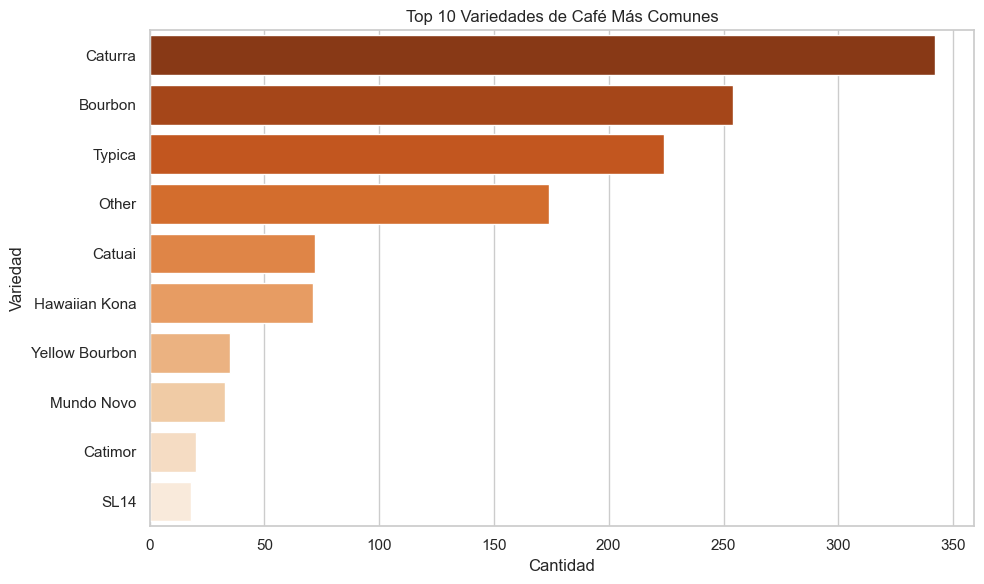

,Cantidad
Variety,
Caturra,342
Bourbon,254
Typica,224
Other,174
Catuai,72
Hawaiian Kona,71
Yellow Bourbon,35
Mundo Novo,33
Catimor,20


In [30]:
top_variedades = df['Variety'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_variedades.values, y=top_variedades.index, hue=top_variedades.index, palette='Oranges_r', legend=False)
plt.title("Top 10 Variedades de Café Más Comunes")
plt.xlabel("Cantidad")
plt.ylabel("Variedad")
plt.tight_layout()
plt.show()

top_variedades.to_frame(name='Cantidad')

# 26. Análisis por categoría de altitud

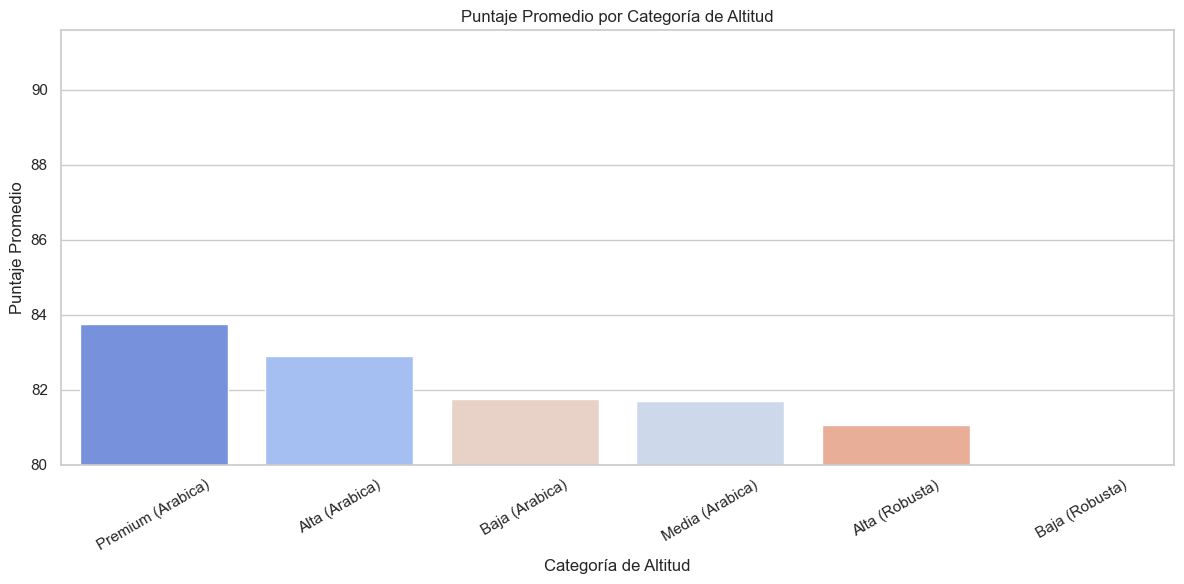

,Puntaje Promedio,Muestras
categoria_altitud,,
Premium (Arabica),83.76,115
Alta (Arabica),82.89,310
Baja (Arabica),81.75,396
Media (Arabica),81.71,483
Alta (Robusta),81.06,26
Baja (Robusta),78.41,2


In [31]:
orden_cat = df.groupby('categoria_altitud')['Total.Cup.Points'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x='categoria_altitud',
    y='Total.Cup.Points',
    order=orden_cat,
    hue='categoria_altitud',
    palette='coolwarm',
    legend=False,
    errorbar=None
)
plt.xticks(rotation=30)
plt.title("Puntaje Promedio por Categoría de Altitud")
plt.xlabel("Categoría de Altitud")
plt.ylabel("Puntaje Promedio")
plt.ylim(80, df['Total.Cup.Points'].max() + 1)
plt.tight_layout()
plt.show()

df.groupby('categoria_altitud')['Total.Cup.Points'].agg(['mean', 'count']).rename(columns={'mean': 'Puntaje Promedio', 'count': 'Muestras'}).round(2).sort_values('Puntaje Promedio', ascending=False)


# 27. Puntaje Promedio por Especie

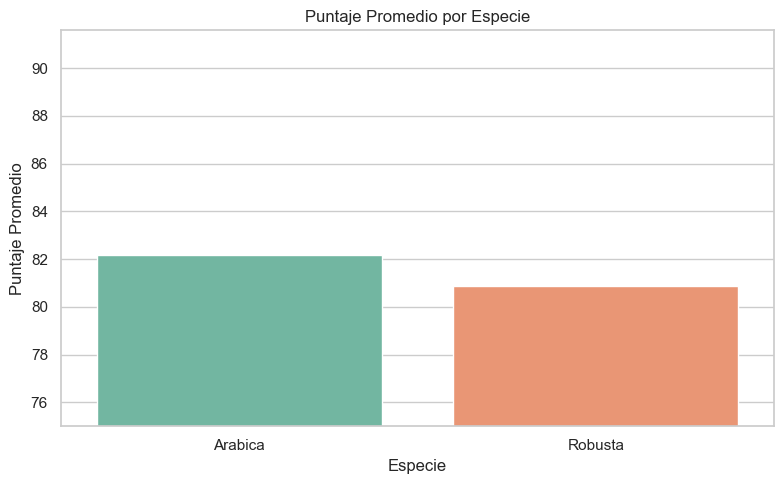

,Puntaje Promedio,Muestras
Species,,
Arabica,82.18,1304
Robusta,80.87,28


In [32]:
resumen_species = (
    df.groupby('Species')['Total.Cup.Points']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Puntaje Promedio', 'count': 'Muestras'})
    .round(2)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x='Species',
    y='Total.Cup.Points',
    hue='Species',
    palette='Set2',
    legend=False,
    errorbar=None
)
plt.title("Puntaje Promedio por Especie")
plt.xlabel("Especie")
plt.ylabel("Puntaje Promedio")
plt.ylim(75, df['Total.Cup.Points'].max() + 1)
plt.tight_layout()
plt.show()

resumen_species

# 28a. Puntaje máximo por especie usando Grading.Date

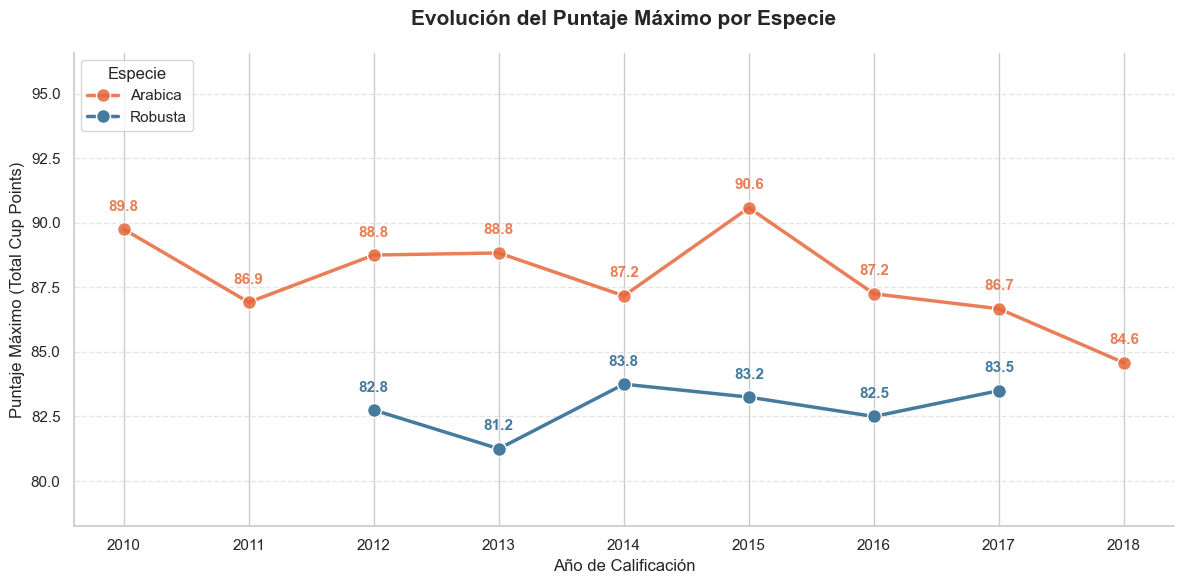

In [33]:
df['Grading.Date'] = pd.to_datetime(df['Grading.Date'], format='mixed', dayfirst=False)
df['Year'] = df['Grading.Date'].dt.year


max_especie_anual = (
    df.groupby(['Year', 'Species'])['Total.Cup.Points']
    .max()
    .unstack()
)

plt.figure(figsize=(12, 6), facecolor='white')
colors = {'Arabica': "#E66739D7", 'Robusta': '#457B9D'}

for especie in max_especie_anual.columns:
    plt.plot(
        max_especie_anual.index, 
        max_especie_anual[especie], 
        label=especie, 
        color=colors.get(especie, 'black'),
        marker='o',      
        linewidth=2.5,     
        markersize=10,     
        markeredgecolor='white', 
        zorder=3             
    )

    for x, y in zip(max_especie_anual.index, max_especie_anual[especie]):
        if not pd.isna(y):
            plt.text(
                x, y + 0.6, f'{y:.1f}',
                ha='center', va='bottom', 
                fontsize=11,          
                color=colors.get(especie, 'black'), 
                fontweight='bold'
            )
plt.title("Evolución del Puntaje Máximo por Especie", fontsize=15, pad=20, fontweight='bold')
plt.xlabel("Año de Calificación", fontsize=12)
plt.ylabel("Puntaje Máximo (Total Cup Points)", fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5, zorder=0)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(title="Especie", loc='upper left', frameon=True)
plt.xticks(max_especie_anual.index) 
plt.ylim(max_especie_anual.min().min() - 3, max_especie_anual.max().max() + 6)
plt.tight_layout()
plt.show()

# 28b. Puntaje promedio por año usando Grading.Date

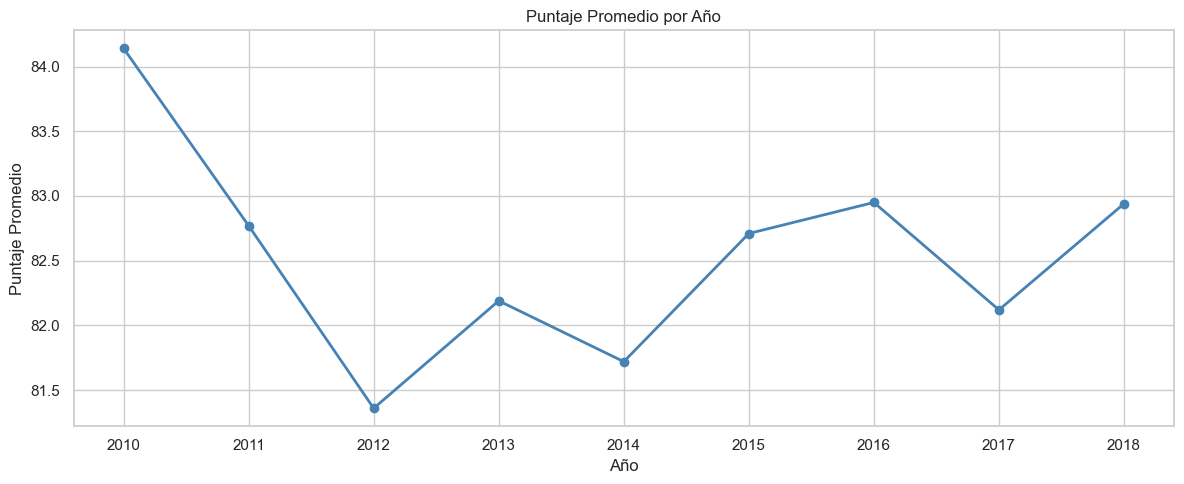

,Puntaje Promedio,Muestras
Year,,
2010,84.14,50
2011,82.77,83
2012,81.36,316
2013,82.19,155
2014,81.72,261
2015,82.71,194
2016,82.95,127
2017,82.12,140
2018,82.94,6


In [34]:
df['Grading.Date'] = pd.to_datetime(df['Grading.Date'], format='mixed', dayfirst=False)
df['Year'] = df['Grading.Date'].dt.year

promedio_anual = df.groupby('Year')['Total.Cup.Points'].agg(['mean', 'count']).rename(columns={'mean': 'Puntaje Promedio', 'count': 'Muestras'}).round(2)

plt.figure(figsize=(12, 5))
promedio_anual['Puntaje Promedio'].plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title("Puntaje Promedio por Año")
plt.xlabel("Año")
plt.ylabel("Puntaje Promedio")
plt.tight_layout()
plt.show()

promedio_anual

# 28c. Mejor Café por Año

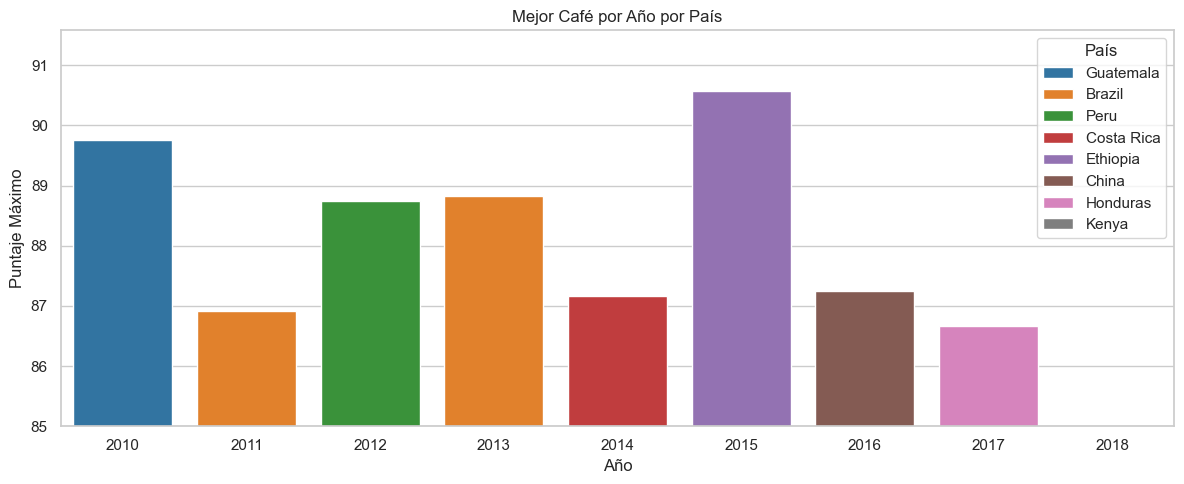

,Year,Country.of.Origin,Variety,Processing.Method,Total.Cup.Points
0,2010,Guatemala,Bourbon,Washed / Wet,89.75
1,2011,Brazil,Bourbon,Natural / Dry,86.92
2,2012,Peru,Other,Washed / Wet,88.75
3,2013,Brazil,Bourbon,Natural / Dry,88.83
4,2014,Costa Rica,Caturra,Washed / Wet,87.17
5,2015,Ethiopia,Other,Washed / Wet,90.58
6,2016,China,Catimor,Washed / Wet,87.25
7,2017,Honduras,Caturra,Washed / Wet,86.67
8,2018,Kenya,SL34,Washed / Wet,84.58


In [35]:
mejor_por_año = (
    df.loc[df.groupby('Year')['Total.Cup.Points'].idxmax()]
    [['Year', 'Country.of.Origin', 'Variety', 'Processing.Method', 'Total.Cup.Points']]
    .sort_values('Year')
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=mejor_por_año,
    x='Year',
    y='Total.Cup.Points',
    hue='Country.of.Origin',
    palette='tab10',
    errorbar=None
)
plt.title("Mejor Café por Año por País")
plt.xlabel("Año")
plt.ylabel("Puntaje Máximo")
plt.ylim(85, mejor_por_año['Total.Cup.Points'].max() + 1)
plt.legend(title='País', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

mejor_por_año

# 28d. Peor Café por Año

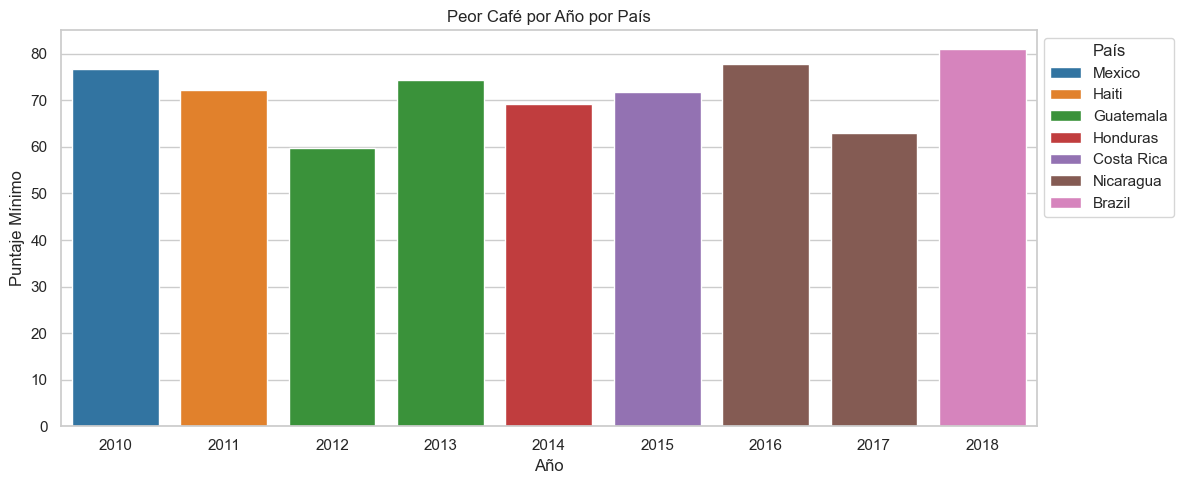

,Year,Country.of.Origin,Variety,Processing.Method,Total.Cup.Points
0,2010,Mexico,Typica,Washed / Wet,76.75
1,2011,Haiti,Typica,Washed / Wet,72.33
2,2012,Guatemala,Catuai,Washed / Wet,59.83
3,2013,Guatemala,Bourbon,Washed / Wet,74.33
4,2014,Honduras,Catuai,Washed / Wet,69.17
5,2015,Costa Rica,Caturra,Washed / Wet,71.75
6,2016,Nicaragua,Caturra,Washed / Wet,77.83
7,2017,Nicaragua,Caturra,Other,63.08
8,2018,Brazil,Bourbon,Pulped Natural / Honey,81.00


In [36]:
peor_por_año = (
    df.loc[df.groupby('Year')['Total.Cup.Points'].idxmin()]
    [['Year', 'Country.of.Origin', 'Variety', 'Processing.Method', 'Total.Cup.Points']]
    .sort_values('Year')
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=peor_por_año,
    x='Year',
    y='Total.Cup.Points',
    hue='Country.of.Origin',
    palette='tab10',
    errorbar=None
)
plt.title("Peor Café por Año por País")
plt.xlabel("Año")
plt.ylabel("Puntaje Mínimo")
plt.legend(title='País', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

peor_por_año

# 29. Análisis de Color

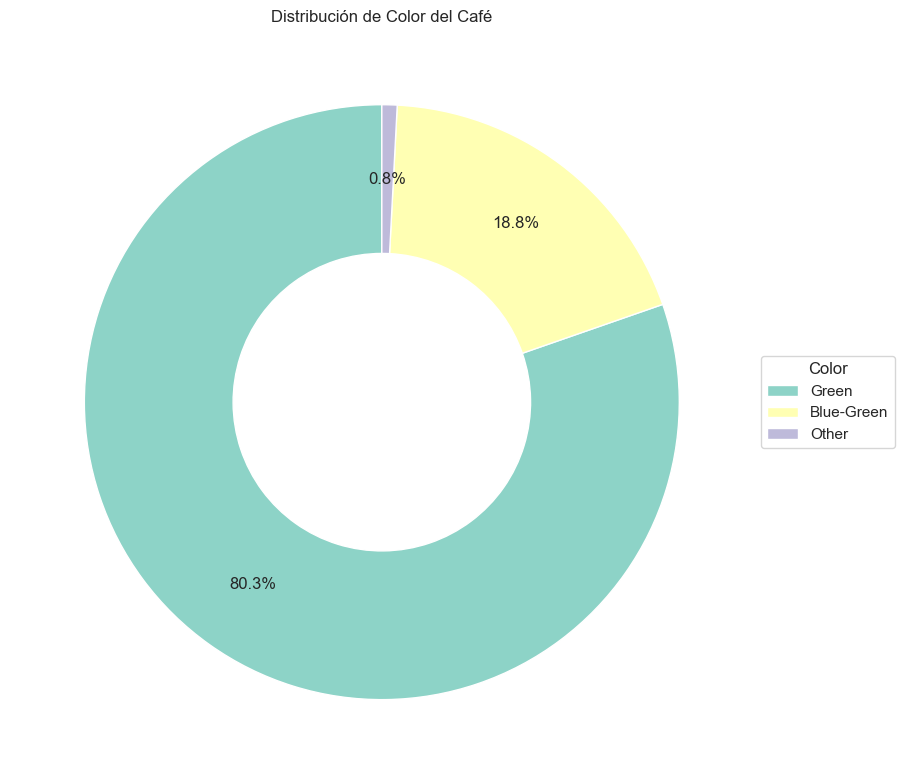

,Muestras
Color,
Green,1070
Blue-Green,251
Other,11


In [37]:
conteo_color = df['Color'].value_counts()

plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    conteo_color.values,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set3', len(conteo_color)),
    wedgeprops=dict(width=0.5),
    pctdistance=0.75
)

plt.legend(
    wedges,
    conteo_color.index,
    title="Color",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)
plt.title("Distribución de Color del Café")
plt.tight_layout()
plt.show()

conteo_color.to_frame(name='Muestras')

# 30. Top 10 regiones con mejor puntaje promedio:

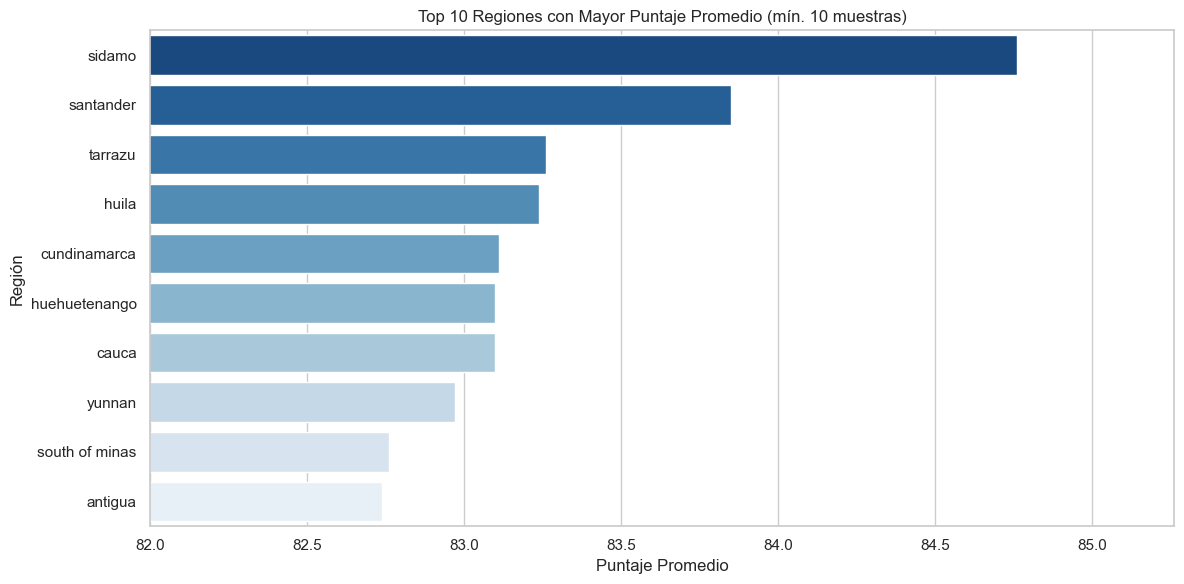

,Puntaje Promedio,Muestras
Region,,
sidamo,84.76,11
santander,83.85,12
tarrazu,83.26,19
huila,83.24,112
cundinamarca,83.11,11
huehuetenango,83.10,15
cauca,83.10,13
yunnan,82.97,13
south of minas,82.76,68


In [38]:
top_regiones = (
    df[df['Region'] != 'No Especificado']
    .groupby('Region')['Total.Cup.Points']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Puntaje Promedio', 'count': 'Muestras'})
    .query('Muestras >= 10')
    .sort_values('Puntaje Promedio', ascending=False)
    .head(10)
    .round(2)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_regiones['Puntaje Promedio'],
    y=top_regiones.index,
    hue=top_regiones.index,
    palette='Blues_r',
    legend=False,
    errorbar=None
)
plt.title("Top 10 Regiones con Mayor Puntaje Promedio (mín. 10 muestras)")
plt.xlabel("Puntaje Promedio")
plt.ylabel("Región")
plt.xlim(82, top_regiones['Puntaje Promedio'].max() + 0.5)
plt.tight_layout()
plt.show()

top_regiones

# 31. Puntaje por In.Country.Partner

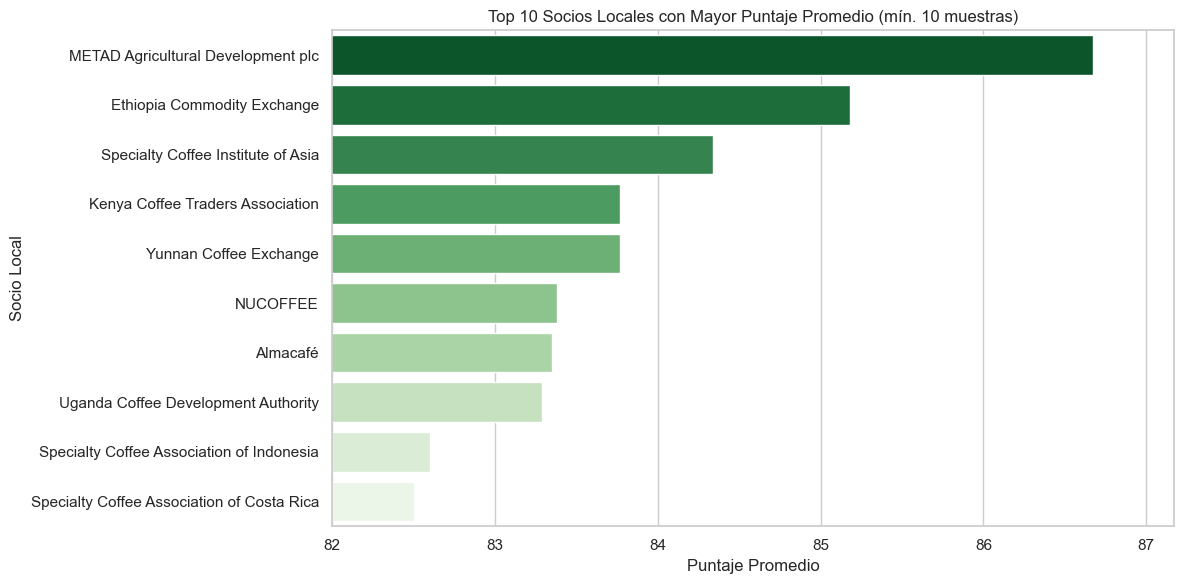

,Puntaje Promedio,Muestras
In.Country.Partner,,
METAD Agricultural Development plc,86.67,15
Ethiopia Commodity Exchange,85.18,18
Specialty Coffee Institute of Asia,84.34,16
Kenya Coffee Traders Association,83.77,22
Yunnan Coffee Exchange,83.77,12
NUCOFFEE,83.38,36
Almacafé,83.35,178
Uganda Coffee Development Authority,83.29,32
Specialty Coffee Association of Indonesia,82.60,10


In [39]:
top_partners = (
    df.groupby('In.Country.Partner')['Total.Cup.Points']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Puntaje Promedio', 'count': 'Muestras'})
    .query('Muestras >= 10')
    .sort_values('Puntaje Promedio', ascending=False)
    .head(10)
    .round(2)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_partners['Puntaje Promedio'],
    y=top_partners.index,
    hue=top_partners.index,
    palette='Greens_r',
    legend=False,
    errorbar=None
)
plt.title("Top 10 Socios Locales con Mayor Puntaje Promedio (mín. 10 muestras)")
plt.xlabel("Puntaje Promedio")
plt.ylabel("Socio Local")
plt.xlim(82, top_partners['Puntaje Promedio'].max() + 0.5)
plt.tight_layout()
plt.show()

top_partners

# 32. Number.of.Bags vs calidad:

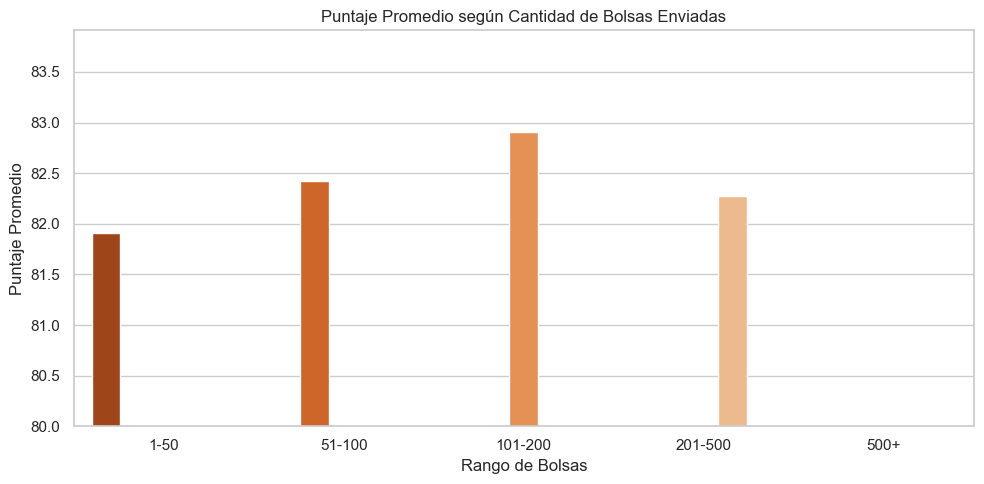

,Puntaje Promedio,Muestras
rango_bolsas,,
1-50,81.91,536
51-100,82.42,80
101-200,82.91,77
201-500,82.27,634
500+,77.56,4


In [40]:
df['rango_bolsas'] = pd.cut(
    df['Number.of.Bags'],
    bins=[0, 50, 100, 200, 500, 10000],
    labels=['1-50', '51-100', '101-200', '201-500', '500+']
)

resumen_bolsas = (
    df.groupby('rango_bolsas', observed=True)['Total.Cup.Points']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Puntaje Promedio', 'count': 'Muestras'})
    .round(2)
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=resumen_bolsas.reset_index(),
    x='rango_bolsas',
    y='Puntaje Promedio',
    hue='rango_bolsas',
    palette='Oranges_r',
    legend=False,
    errorbar=None
)
plt.title("Puntaje Promedio según Cantidad de Bolsas Enviadas")
plt.xlabel("Rango de Bolsas")
plt.ylabel("Puntaje Promedio")
plt.ylim(80, resumen_bolsas['Puntaje Promedio'].max() + 1)
plt.tight_layout()
plt.show()

resumen_bolsas

Los productores que envían entre 101 y 200 bolsas obtienen el mayor puntaje promedio con 82.91 puntos, seguidos por los que envían entre 51 y 100 bolsas con 82.42. Los productores más pequeños (1-50 bolsas) y los medianos (201-500) tienen puntajes similares alrededor de 82 puntos. El rango 500+ tiene el puntaje más bajo con 77.56, aunque solo cuenta con 4 muestras, lo que hace que ese dato no sea representativo. En general, no se observa una tendencia clara que indique que producir más volumen se traduzca en mayor o menor calidad.

# 33. Mejor Café del Dataset

In [41]:
mejor_cafe = df.loc[df['Total.Cup.Points'].idxmax()]
print("Mejor Café del Dataset")
print("=" * 40)
print(mejor_cafe)

Mejor Café del Dataset
Species                                            Arabica
Owner                                            metad plc
Country.of.Origin                                 Ethiopia
Region                                        guji-hambela
Number.of.Bags                                         300
Bag.Weight                                           60 kg
In.Country.Partner      METAD Agricultural Development plc
Grading.Date                           2015-04-04 00:00:00
Variety                                              Other
Processing.Method                             Washed / Wet
Aroma                                                 8.67
Flavor                                                8.83
Aftertaste                                            8.67
Acidity                                               8.75
Body                                                   8.5
Balance                                               8.42
Cupper.Points                    